In [1]:
import ast
import io
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Academic paper style: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Text width of a two-column paper (\textwidth for figure*/table*), in inches.
PAGE_W = 7.0
COL_W = 3.35

# Consistent colors: HRM-Text is the accent, baselines are muted greys/blues.
ACCENT = "#c0392b"        # HRM-Text, direct
ACCENT_LIGHT = "#e07b6f"  # HRM-Text, Meta-ICL
MUTED = "#7f8c8d"         # LLM baseline, direct
MUTED_LIGHT = "#b9c0c4"   # LLM baseline, Meta-ICL
TRM_COLOR = "#2c6fbb"     # TRM comparison


def save_fig(fig, name):
    """Export a figure as both vector PDF and raster PNG for the paper."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig


def bold_best(tbl, fmt, decimals, skip_rows=(), na_rep="--"):
    """Format a numeric table for LaTeX with each column's best value in bold.

    Ties at the displayed precision are all bolded. `skip_rows` (e.g. a random-answer
    control) are formatted but never compete for the best value.
    """
    out = tbl.map(lambda v: na_rep if pd.isna(v) else fmt(v)).astype(object)
    rounded = tbl.drop(index=list(skip_rows), errors="ignore").round(decimals)
    for col in tbl.columns:
        best = rounded[col].max()
        if pd.isna(best):
            continue
        for idx in rounded.index[rounded[col] == best]:
            out.loc[idx, col] = rf"\textbf{{{out.loc[idx, col]}}}"
    return out


HRM_ARCH = "HRM-Text-1B"

# Short display names keyed by the HuggingFace id found in the run's `model` config.
ARCH_LABELS = {
    "sapientinc/HRM-Text-1B": HRM_ARCH,
    "danish-foundation-models/DFM-Mimir": "DFM-Mimir",
    "ByteDance/Ouro-1.4B": "Ouro-1.4B",
    "google/gemma-4-31B": "Gemma-4-31B",
    "mistralai/Mistral-7B-v0.3": "Mistral-7B",
    "Qwen/Qwen3-4B": "Qwen3-4B",
    "Qwen/Qwen2.5-3B": "Qwen2.5-3B",
    "HuggingFaceTB/SmolLM2-1.7B": "SmolLM2-1.7B",
    "Qwen/Qwen2.5-1.5B": "Qwen2.5-1.5B",
    "meta-llama/Llama-3.2-1B": "Llama-3.2-1B",
    "google/gemma-3-1b-pt": "Gemma-3-1B",
    "Qwen/Qwen3-0.6B": "Qwen3-0.6B",
}

DIRECT, META_ICL = "Standard SFT", "Meta-ICL"

# Architecture family of each model, used to group rows in RQ1 and RQ3. A model not listed
# here is a standard (non-recurrent) transformer.
HRM_FAMILY, LOOPED_FAMILY, TF_FAMILY = "HRM", "Looped transformer", "Standard transformer"
FAMILY_ORDER = [HRM_FAMILY, LOOPED_FAMILY, TF_FAMILY]
ARCH_FAMILY = {HRM_ARCH: HRM_FAMILY, "DFM-Mimir": HRM_FAMILY, "Ouro-1.4B": LOOPED_FAMILY}
FAMILY_SHORT = {HRM_FAMILY: "HRM", LOOPED_FAMILY: "Looped", TF_FAMILY: "Transformer"}  # rotated table labels
# Bar colors per family, (standard SFT, Meta-ICL). Grey keeps the standard transformers recessive.
LOOPED_COLOR, LOOPED_LIGHT = "#2c6fbb", "#93b7e3"
FAMILY_COLORS = {HRM_FAMILY: (ACCENT, ACCENT_LIGHT), LOOPED_FAMILY: (LOOPED_COLOR, LOOPED_LIGHT),
                 TF_FAMILY: (MUTED, MUTED_LIGHT)}


def arch_family(arch):
    return ARCH_FAMILY.get(arch, TF_FAMILY)


def group_by_family(archs):
    """`archs` reordered family by family (FAMILY_ORDER), keeping their order within a family."""
    return [a for fam in FAMILY_ORDER for a in archs if arch_family(a) == fam]

# Gradient regimes compared in the recursion study (RQ2.1').
TRUNC_BP, FULL_BP = "Truncated BPTT (5 blocks)", "Full backprop"

# The 11 GraphQA reasoning tasks (column suffixes in the performance data).
GRAPH_TASKS = [
    "ConnectedNodes", "CycleCheck", "DisconnectedNodes", "EdgeCount",
    "EdgeExistence", "MaximumFlow", "NodeCount", "NodeDegree",
    "Reachability", "ShortestPath", "TriangleCounting",
]

# Compact task headers so an 11-column heatmap/table fits the page width.
TASK_ABBREV = {
    "ConnectedNodes": "ConnNod", "CycleCheck": "Cycle",
    "DisconnectedNodes": "DisconnNod", "EdgeCount": "EdgeCnt",
    "EdgeExistence": "EdgeExist", "MaximumFlow": "MaxFlow",
    "NodeCount": "NodeCnt", "NodeDegree": "NodeDeg",
    "Reachability": "Reach", "ShortestPath": "ShortPath",
    "TriangleCounting": "TriCount",
}


In [2]:
# Some W&B exports wrap each row in an extra layer of quotes (doubled inner quotes), so a
# plain read_csv collapses everything into one column. Unwrap only in that case: on a
# regular fully-quoted export, stripping the outer quotes would shift every column.
def read_wandb_csv(path):
    df = pd.read_csv(path)
    if df.shape[1] > 1:
        return df
    lines = [ln for ln in Path(path).read_text().splitlines() if ln]
    unwrapped = [
        ln[1:-1].replace('""', '"') if ln.startswith('"') and ln.endswith('"') else ln
        for ln in lines
    ]
    return pd.read_csv(io.StringIO("\n".join(unwrapped)))


RESULTS_DIR = Path("data/results")

ablation_data = read_wandb_csv(RESULTS_DIR / "ablation_data.csv")

# The v2 exports are plain CSVs, one file per (model family, evaluation split). Column
# *order* differs between families, so concat aligns on names and NaN-fills the rest.
V2_DIR = RESULTS_DIR / "v2"
V2_FAMILIES = ["baseline", "meta-icl", "hrm", "hrm-meta-icl"]
# Late additions, evaluated in-distribution only: no Meta-ICL and no OOD sweep.
V2_ID_ONLY = ["additional_baselines"]


def load_v2(split):
    families = V2_FAMILIES + (V2_ID_ONLY if split == "id" else [])
    return pd.concat(
        [pd.read_csv(V2_DIR / f"{fam}-{split}.csv") for fam in families],
        ignore_index=True,
    )


performance_data = load_v2("id")
# Leave-one-task-out OOD: one run per held-out task, per model.
ood_data = load_v2("ood")

print(f"ID runs: {len(performance_data)}   OOD runs: {len(ood_data)}")


ID runs: 24   OOD runs: 198


# RQ1 — Performance: HRM-Text vs. baselines

Exact-match accuracy on GraphQA over **11 architectures** (20 runs): HRM-Text-1B plus 10
open-weight LLM backbones (Gemma-4-31B, Mistral-7B, Qwen3-4B, Qwen2.5-3B, SmolLM2-1.7B,
Qwen2.5-1.5B, Llama-3.2-1B, Gemma-3-1B, Qwen3-0.6B, DFM-Mimir). Nine of them are trained
under **both** regimes — **directly** and with **Meta-ICL** — while the two late additions
(Gemma-4-31B and DFM-Mimir) were run **direct-only and in-distribution only**; their
Meta-ICL and OOD cells are reported as `--`.

In-distribution (`standard`) results use all 11 tasks. Out-of-distribution generalization is
measured **leave-one-task-out**: each GraphQA task is held out in turn and the model
evaluated on that unseen task; the reported OOD number is the mean over the 11 held-out runs.

> **Caption note:** the ID and OOD panels use *different x-scales*. OOD accuracy is roughly
> an order of magnitude lower than ID, so a shared 0–1 axis would flatten every OOD bar.


In [3]:
# `dataset` and `model` are dict-strings holding the run config. The W&B run `Name`
# is NOT unique (both HRM variants export as "hrm-text-id"), so every key below is
# derived from (architecture, regime) instead.
def enrich(df):
    out = df.copy()
    dataset = out["dataset"].map(ast.literal_eval)
    out["test_type"] = dataset.map(lambda d: d["test_type"])
    out["dataset_config"] = dataset.map(lambda d: d["dataset_config"])
    out["task"] = dataset.map(lambda d: d["ood_task"])
    out["arch"] = out["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    out["regime"] = np.where(out["dataset_config"] == "meta-icl", META_ICL, DIRECT)
    out["model"] = np.where(
        out["regime"] == META_ICL, out["arch"] + f" ({META_ICL})", out["arch"]
    )
    out["exact_match"] = out["val/exact_match"].astype(float)
    return out


perf_id = (
    enrich(performance_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime"], keep="last")
    .reset_index(drop=True)
)

# For OOD runs only the held-out task's column is populated, so `val/exact_match`
# already is that task's score.
ood = (
    enrich(ood_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime", "task"], keep="last")
    .reset_index(drop=True)
)

# One shared ordering: architectures ranked by direct-regime ID accuracy, HRM-Text
# pinned first; rows are then grouped into a Direct block and a Meta-ICL block.
_direct_rank = (
    perf_id[perf_id["regime"] == DIRECT]
    .set_index("arch")["exact_match"]
    .sort_values(ascending=False)
)
ARCH_ORDER = [HRM_ARCH] + [a for a in _direct_rank.index if a != HRM_ARCH]
# The ID-only additions have no Meta-ICL counterpart, so the two blocks differ in size.
_have_meta = set(perf_id.loc[perf_id["regime"] == META_ICL, "arch"])
META_ORDER = [f"{a} ({META_ICL})" for a in ARCH_ORDER if a in _have_meta]
MODEL_ORDER = ARCH_ORDER + META_ORDER
N_DIRECT = len(ARCH_ORDER)

perf_id["model"] = pd.Categorical(perf_id["model"], MODEL_ORDER, ordered=True)
perf_id = perf_id.sort_values("model").reset_index(drop=True)
perf_id["model"] = perf_id["model"].astype(str)

# Models x held-out-task matrix (canonical task order) + mean OOD per model.
ood_by_task = (
    ood.pivot(index="model", columns="task", values="exact_match")
    .reindex(index=MODEL_ORDER, columns=GRAPH_TASKS)
)
# Models x task matrix for the in-distribution runs.
id_by_task = perf_id.set_index("model")[[f"val/exact_match_{t}" for t in GRAPH_TASKS]]
id_by_task.columns = GRAPH_TASKS
id_by_task = id_by_task.reindex(MODEL_ORDER)

overall_id = perf_id.set_index("model")["exact_match"].reindex(MODEL_ORDER)
overall_ood = ood_by_task.mean(axis=1)

# Models evaluated OOD must be complete; the ID-only additions are allowed to be absent.
OOD_MODELS = [m for m in MODEL_ORDER if m in set(ood["model"])]
# assert len(perf_id) == len(MODEL_ORDER) == 20, "unexpected v2 coverage"
assert id_by_task.notna().all().all(), "missing in-distribution per-task scores"
assert ood_by_task.loc[OOD_MODELS].notna().all().all(), "incomplete OOD sweep"
pd.DataFrame({"ID": overall_id, "OOD (mean)": overall_ood}).round(3)


,ID,OOD (mean)
model,,
HRM-Text-1B,0.831,0.407
DFM-Mimir,0.847,NaN
Gemma-4-31B,0.813,NaN
Ouro-1.4B,0.727,NaN
Qwen3-0.6B,0.725,0.133
Qwen3-4B,0.722,0.279
Qwen2.5-3B,0.717,0.120
Qwen2.5-1.5B,0.701,0.092
SmolLM2-1.7B,0.686,0.141


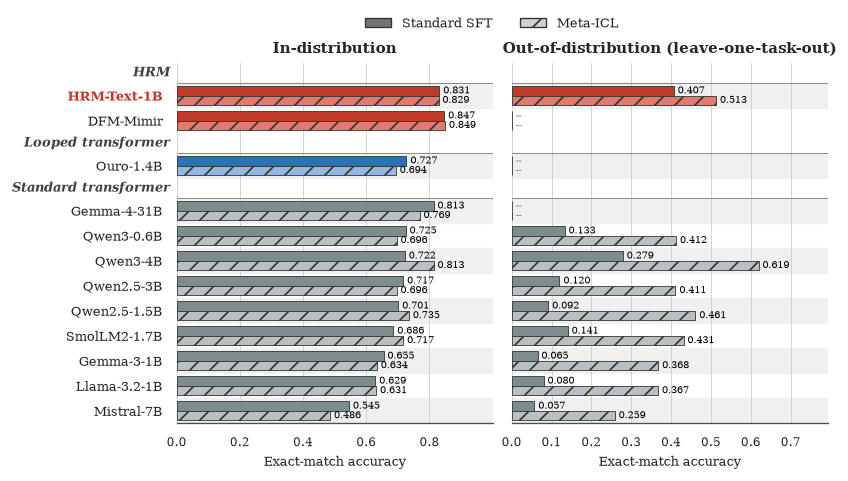

In [4]:
# Main RQ1 figure (full-width `figure*`): one row per architecture, paired bars for the
# standard-SFT and Meta-ICL regimes. Rows are grouped by architecture family, each group under a
# bold header; bar color = family (dark: standard SFT, light + hatch: Meta-ICL). ID and OOD sit in
# separate panels because OOD accuracy is much smaller and would be invisible on a shared 0-1 axis.
def plot_id_ood_panels(fname="perf_overall_id_ood"):
    order = group_by_family(ARCH_ORDER)
    # Row centers top to bottom; each family gets a header slot above its rows.
    header_h, ypos, headers, cursor = 0.8, {}, [], -0.5
    for fam in FAMILY_ORDER:
        members = [a for a in order if arch_family(a) == fam]
        if not members:
            continue
        headers.append((fam, cursor + header_h / 2, cursor + header_h, cursor + header_h + len(members)))
        cursor += header_h
        for a in members:
            ypos[a] = cursor + 0.5
            cursor += 1
    y = np.array([ypos[a] for a in order])
    h = 0.38
    fig_h = 3.9
    fig, axes = plt.subplots(
        1, 2, figsize=(PAGE_W, fig_h), sharey=True, gridspec_kw={"wspace": 0.06}
    )

    panels = [
        (axes[0], overall_id, "In-distribution", (0, 1.0)),
        (axes[1], overall_ood, "Out-of-distribution (leave-one-task-out)", None),
    ]
    for ax, series, title, xlim in panels:
        for _, _, lo, hi_row in headers:  # light bands on every other row within a family
            for k, start in enumerate(np.arange(lo, hi_row)):
                if k % 2 == 0:
                    ax.axhspan(start, start + 1, color="0.94", zorder=0)
            ax.axhline(lo, color="0.55", linewidth=0.6, zorder=1)

        direct = np.array([series.get(a, np.nan) for a in order], dtype=float)
        meta = np.array([series.get(f"{a} ({META_ICL})", np.nan) for a in order], dtype=float)
        colors = [FAMILY_COLORS[arch_family(a)] for a in order]

        groups = [
            (y - h / 2, direct, [c[0] for c in colors], None),
            (y + h / 2, meta, [c[1] for c in colors], "//"),
        ]
        top = np.nanmax(np.concatenate([direct, meta]))
        hi = xlim[1] if xlim else top * 1.28
        for ypos_, vals, cols, hatch in groups:
            bars = ax.barh(ypos_, np.nan_to_num(vals), height=h, color=cols,
                           edgecolor="0.2", linewidth=0.5, hatch=hatch, zorder=2)
            for bar, v in zip(bars, vals):
                # Runs that were never evaluated in this cell get a dash, not a 0.000.
                label = "--" if np.isnan(v) else f"{v:.3f}"
                ax.text(np.nan_to_num(v) + hi * 0.012,
                        bar.get_y() + bar.get_height() / 2,
                        label, va="center", ha="left", fontsize=6,
                        color="0.55" if np.isnan(v) else "black", zorder=3)

        ax.set_xlim(0, hi)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Exact-match accuracy", fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.grid(axis="y", visible=False)
        ax.set_axisbelow(True)

    # Drop the left panel's final tick so it does not collide with the right panel's 0.0.
    axes[0].set_xticks(np.arange(0, 1.0, 0.2))
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(order, fontsize=8)
    axes[0].set_ylim(cursor, -0.5)  # first family on top
    for lbl, a in zip(axes[0].get_yticklabels(), order):
        if a == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")
    # Family headers in the label column, right-aligned with the model names.
    for fam, hy, _, _ in headers:
        axes[0].annotate(fam, xy=(0, hy), xycoords=("axes fraction", "data"),
                         xytext=(-4, 0), textcoords="offset points", ha="right", va="center",
                         fontsize=7.5, fontweight="bold", fontstyle="italic", color="0.25",
                         annotation_clip=False)

    # Regime legend in neutral greys: fill and hatch encode the regime, color the family.
    handles = [
        mpl.patches.Patch(facecolor="0.45", edgecolor="0.2", label=DIRECT),
        mpl.patches.Patch(facecolor="0.82", edgecolor="0.2", hatch="//", label=META_ICL),
    ]
    # Sit the legend just above the panel titles (9pt title + pad), with no dead band.
    fig.legend(handles=handles, loc="lower center",
               bbox_to_anchor=(0.5, axes[0].get_position().y1 + 0.17 / fig_h),
               ncol=2, fontsize=8, frameon=False)
    sns.despine(fig=fig, left=True)
    save_fig(fig, fname)
    plt.show()


plot_id_ood_panels()


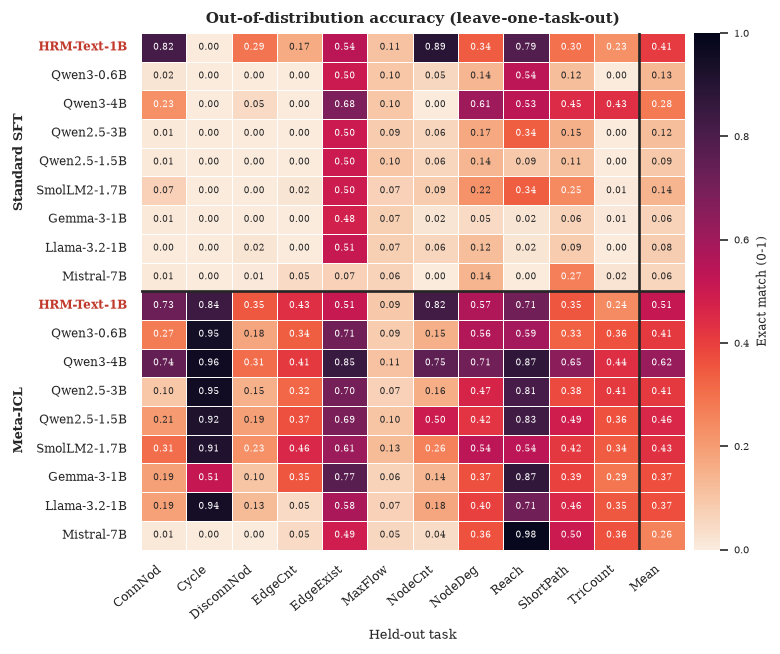

In [5]:
# Full-width per-task heatmap: rows are (architecture x regime) split into a Direct block
# and a Meta-ICL block, so a row label only needs the architecture name.
def plot_task_heatmap(mat, title, fname, vmax, xlabel=""):
    mat = mat.dropna(how="all")  # ID-only additions have no OOD sweep
    block = sum(META_ICL not in str(m) for m in mat.index)
    annotated = mat.copy()
    annotated["Mean"] = mat.mean(axis=1)

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.255 * len(mat) + 1.0))
    sns.heatmap(
        annotated, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=vmax,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
        cbar_kws={"label": f"Exact match (0-{vmax:g})", "pad": 0.015}, ax=ax,
    )
    ax.axhline(block, color="0.15", linewidth=1.6)          # regime separator
    ax.axvline(len(GRAPH_TASKS), color="0.15", linewidth=1.6)  # Mean separator

    ax.set_xticklabels([TASK_ABBREV.get(c, c) for c in annotated.columns],
                       rotation=40, ha="right", fontsize=7)
    ax.set_yticklabels([str(m).replace(f" ({META_ICL})", "") for m in mat.index],
                       rotation=0, fontsize=7)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    # Label each regime block once, clear of the architecture tick labels.
    for name, lo, hi in [(DIRECT, 0, block), (META_ICL, block, len(mat))]:
        ax.text(-0.225, (lo + hi) / 2, name, transform=ax.get_yaxis_transform(),
                rotation=90, va="center", ha="center", fontsize=8, fontweight="bold")

    ax.set_ylabel("")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


# OOD accuracy is far below 1.0 on most cells, so derive the color cap from the data.
ood_vmax = np.ceil(np.nanmax(ood_by_task.to_numpy()) * 10) / 10
plot_task_heatmap(
    ood_by_task,
    "Out-of-distribution accuracy (leave-one-task-out)",
    "perf_ood_by_task",
    vmax=ood_vmax,
    xlabel="Held-out task",
)

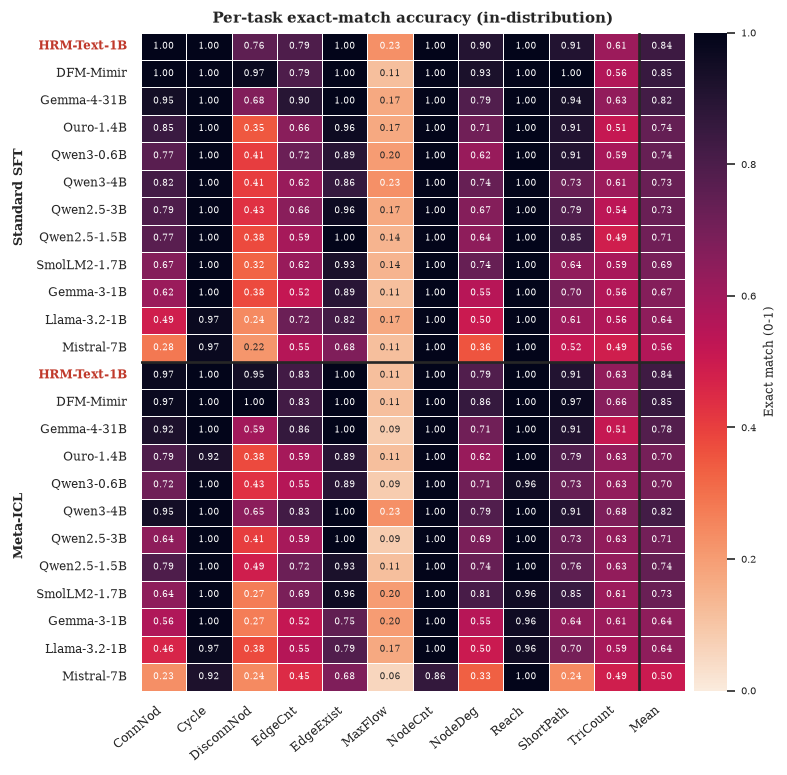

In [6]:
plot_task_heatmap(
    id_by_task,
    "Per-task exact-match accuracy (in-distribution)",
    "perf_by_task",
    vmax=1.0,
)


In [7]:
# Single full-width `table*`: models as rows (Direct / Meta-ICL blocks), the 11 tasks plus
# a Mean as column groups, each split into an ID and an OOD sub-column.
def combined_task_table_latex(id_mat, ood_mat, caption, label):
    def with_mean(mat):
        out = mat.copy()
        out["Mean"] = mat.mean(axis=1)
        return out

    idm, oodm = with_mean(id_mat), with_mean(ood_mat)
    groups = [TASK_ABBREV.get(c, c) for c in idm.columns]
    tbl = pd.concat(
        {g: pd.DataFrame({"ID": idm[c], "OOD": oodm[c]})
         for g, c in zip(groups, idm.columns)},
        axis=1,
    ).reindex(columns=pd.MultiIndex.from_product([groups, ["ID", "OOD"]]))

    # Drop the leading zero (".84") so 24 numeric columns still fit the text width.
    def fmt(v):
        return f"{v:.2f}".lstrip("0") if v < 1 else f"{v:.2f}"

    # Best model per (task, split) column, across both regimes.
    tbl = bold_best(tbl, fmt, 2)
    tbl.index = [str(m).replace(f" ({META_ICL})", "") for m in id_mat.index]

    lines = tbl.to_latex(
        column_format="l|" + "cc|" * (len(groups) - 1) + "cc",
        escape=False, na_rep="--", multicolumn=True, multicolumn_format="c",
    ).splitlines()

    ncol = 1 + 2 * len(groups)
    # The two regime blocks differ in size: some architectures are direct-only.
    n_direct = sum(META_ICL not in str(m) for m in id_mat.index)
    n_rows = len(tbl)
    head = lines.index(r"\midrule")
    rows = lines[head + 1: head + 1 + n_rows]
    for i in (0, n_direct):  # HRM-Text is pinned first in each block
        rows[i] = rows[i].replace(HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1)

    cmid = " ".join(
        rf"\cmidrule(lr){{{2 + 2 * j}-{3 + 2 * j}}}" for j in range(len(groups))
    )

    def banner(name):
        return rf"\multicolumn{{{ncol}}}{{l}}{{\textit{{{name}}}}} \\"

    top = lines.index(r"\toprule")
    body = (
        lines[: top + 2] + [cmid] + lines[top + 2: head + 1]
        + [banner(DIRECT)] + rows[:n_direct]
        + [r"\midrule", banner(META_ICL)] + rows[n_direct:]
        + lines[head + 1 + n_rows:]
    )
    return "\n".join([
        r"\begin{table*}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        *body,
        r"}",
        r"\end{table*}",
    ])


print(combined_task_table_latex(
    id_by_task,
    ood_by_task,
    "GraphQA exact-match accuracy per task. \\textbf{ID}: in-distribution. "
    "\\textbf{OOD}: leave-one-task-out, i.e.\\ the task was held out of training. "
    "Gemma-4-31B and DFM-Mimir were run in-distribution only, so their OOD cells are "
    "\\texttt{--}. Best model per column in bold. Leading zeros omitted.",
    "tab:perf_by_task",
))


\begin{table*}[t]
\centering
\small
\caption{GraphQA exact-match accuracy per task. \textbf{ID}: in-distribution. \textbf{OOD}: leave-one-task-out, i.e.\ the task was held out of training. Gemma-4-31B and DFM-Mimir were run in-distribution only, so their OOD cells are \texttt{--}. Best model per column in bold. Leading zeros omitted.}
\label{tab:perf_by_task}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{ConnNod} & \multicolumn{2}{c}{Cycle} & \multicolumn{2}{c}{DisconnNod} & \multicolumn{2}{c}{EdgeCnt} & \multicolumn{2}{c}{EdgeExist} & \multicolumn{2}{c}{MaxFlow} & \multicolumn{2}{c}{NodeCnt} & \multicolumn{2}{c}{NodeDeg} & \multicolumn{2}{c}{Reach} & \multicolumn{2}{c}{ShortPath} & \multicolumn{2}{c}{TriCount} & \multicolumn{2}{c}{Mean} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11} \cmidrule(lr){12-13} \cmidrule(lr){14-15} \cmidrule(lr){16-17} \cmidrule(lr){18-19} 

In [8]:
# Compact single-column headline table: 11 architectures x {ID, OOD} x {Direct, Meta-ICL}.
# The old per-task ID/OOD cross-table would have needed 44 numeric columns.
summary = pd.DataFrame(
    {
        ("ID", DIRECT): overall_id.reindex(ARCH_ORDER).to_numpy(),
        ("ID", META_ICL): overall_id.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
        ("OOD", DIRECT): overall_ood.reindex(ARCH_ORDER).to_numpy(),
        ("OOD", META_ICL): overall_ood.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
    },
    index=ARCH_ORDER,
)
summary.columns = pd.MultiIndex.from_tuples(summary.columns)

summary_lines = bold_best(summary, "{:.3f}".format, 3).to_latex(
    column_format="l|cc|cc",
    escape=False,
    na_rep="--",
    multicolumn=True,
    multicolumn_format="c",
).splitlines()
head = summary_lines.index(r"\midrule")
summary_lines[head + 1] = summary_lines[head + 1].replace(
    HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1
)

print("\n".join([
    r"\begin{table}[t]", r"\centering", r"\small",
    r"\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 "
    r"leave-one-task-out evaluations. Gemma-4-31B and DFM-Mimir were run under the "
    r"standard-SFT regime in-distribution only; \texttt{--} marks an evaluation that "
    r"was not performed. Best model per column in bold.}",
    r"\label{tab:perf_summary}",
    *summary_lines,
    r"\end{table}",
]))

summary.round(3)


\begin{table}[t]
\centering
\small
\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 leave-one-task-out evaluations. Gemma-4-31B and DFM-Mimir were run under the standard-SFT regime in-distribution only; \texttt{--} marks an evaluation that was not performed. Best model per column in bold.}
\label{tab:perf_summary}
\begin{tabular}{l|cc|cc}
\toprule
 & \multicolumn{2}{c}{ID} & \multicolumn{2}{c}{OOD} \\
 & Standard SFT & Meta-ICL & Standard SFT & Meta-ICL \\
\midrule
\textbf{HRM-Text-1B} & 0.831 & 0.829 & \textbf{0.407} & 0.513 \\
DFM-Mimir & \textbf{0.847} & \textbf{0.849} & -- & -- \\
Gemma-4-31B & 0.813 & 0.769 & -- & -- \\
Ouro-1.4B & 0.727 & 0.694 & -- & -- \\
Qwen3-0.6B & 0.725 & 0.696 & 0.133 & 0.412 \\
Qwen3-4B & 0.722 & 0.813 & 0.279 & \textbf{0.619} \\
Qwen2.5-3B & 0.717 & 0.696 & 0.120 & 0.411 \\
Qwen2.5-1.5B & 0.701 & 0.735 & 0.092 & 0.461 \\
SmolLM2-1.7B & 0.686 & 0.717 & 0.141 & 0.431 \\
Gemma-3-1B & 0.655 & 0.634 & 0.065 & 0.368 \\
Llama-3.2-1B & 0.629 & 

ID                   OOD         
             Standard SFT Meta-ICL Standard SFT Meta-ICL
HRM-Text-1B         0.831    0.829        0.407    0.513
DFM-Mimir           0.847    0.849          NaN      NaN
Gemma-4-31B         0.813    0.769          NaN      NaN
Ouro-1.4B           0.727    0.694          NaN      NaN
Qwen3-0.6B          0.725    0.696        0.133    0.412
Qwen3-4B            0.722    0.813        0.279    0.619
Qwen2.5-3B          0.717    0.696        0.120    0.411
Qwen2.5-1.5B        0.701    0.735        0.092    0.461
SmolLM2-1.7B        0.686    0.717        0.141    0.431
Gemma-3-1B          0.655    0.634        0.065    0.368
Llama-3.2-1B        0.629    0.631        0.080    0.367
Mistral-7B          0.545    0.486        0.057    0.259

# RQ2 — Recursion regime: how does recursion impact HRM's capabilities?

RQ1 and RQ3 establish *that* HRM-Text works. RQ2 asks *what the recursion itself buys*, by
varying the recurrent regime rather than the data. It decomposes into:

| Sub-question | Asks | Status |
| --- | --- | --- |
| **RQ2.1** | How does it vary over the $L/H$ parameter values? | answered below |
| **RQ2.1'** | Is backprop truncation the bottleneck behind the collapse at high recursion depth? | answered below — **no** |
| **RQ2.2** | Does it vary over classes of tasks? | answered below via RQ2.1.1 / RQ2.1.2 |
| **RQ2.1.1** | Does it vary over the *type* of task (KGQA, general knowledge, math, …)? | answered below — optimum and collapse **no**, decay rate **yes** |
| **RQ2.1.2** | Does it vary over the *I/O shape* (long reasoning → short output, vs. short reasoning → long/structured output)? | answered below — **no** (level only) |

---

## RQ2.1 — Varying the $L/H$ parameter values

Two effects on GraphQA test accuracy, shown for both HRM and TRM:

1. **The L/H ratio is decisive (axis 2).** Raising the low-level-to-high-level cycle
   ratio $L/H$ improves accuracy, peaking at the largest ratio. For HRM, ratios below 1
   collapse performance entirely, whereas TRM is markedly more robust to the ratio.
2. **Pure recursion at a fixed ratio hurts.** Holding $L/H = 1.5$ fixed and simply scaling
   up the number of recurrent cycles degrades accuracy to zero — for both HRM and TRM.


In [9]:
# Clean ablation runs: drop those without an eval score, recompute the true L/H ratio.
abl = ablation_data.copy()
abl = abl[abl["eval/accuracy"].notna()].copy()
abl["accuracy"] = abl["eval/accuracy"].astype(float)
abl["H"] = abl["H_cycles"].astype(int)
abl["L"] = abl["L_cycles"].astype(int)
abl["ratio"] = abl["L"] / abl["H"]
abl["family"] = np.where(abl["Name"].str.contains("trm"), "TRM", "HRM")

# Average any repeated (family, H, L) runs. `abl_grid` keeps every measured (H, L) cell and
# feeds only the full-grid heatmap.
abl_grid = (
    abl.groupby(["family", "H", "L", "ratio"], as_index=False)["accuracy"]
    .mean()
    .sort_values(["family", "ratio"])
)
# The RQ2.1 design proper: fixed depth H*L = 12 and fixed ratio L/H = 1.5. Everything
# downstream (sweeps, full-BP comparison, RQ2.2) uses these configurations only. TRM (6, 9)
# was evaluated after the sweep figures were made; it is left out to keep them unchanged.
LATE_EVALS = [("TRM", 6, 9)]
in_sweep = (abl_grid["H"] * abl_grid["L"] == 12) | np.isclose(abl_grid["ratio"], 1.5)
late = pd.Series(list(zip(abl_grid["family"], abl_grid["H"], abl_grid["L"])),
                 index=abl_grid.index).isin(LATE_EVALS)
abl = abl_grid[in_sweep & ~late].reset_index(drop=True)
abl


,family,H,L,ratio,accuracy
0,HRM,6,2,0.333333,0.000000
1,HRM,4,3,0.750000,0.062338
2,HRM,3,4,1.333333,0.400000
3,HRM,2,3,1.500000,0.444156
4,HRM,4,6,1.500000,0.054545
5,HRM,6,9,1.500000,0.000000
6,HRM,8,12,1.500000,0.000000
7,HRM,2,6,3.000000,0.438961
8,HRM,1,12,12.000000,0.514286
9,TRM,6,2,0.333333,0.376623


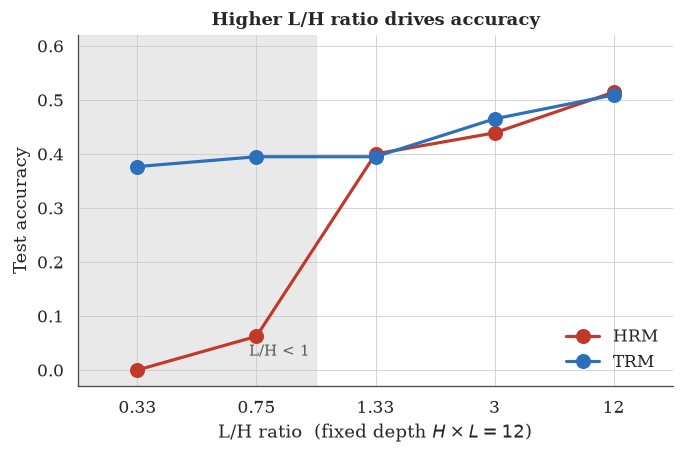

In [10]:
# Axis 2 — ratio effect for HRM and TRM. Hold the total recurrence depth H*L = 12 fixed
# and vary only the L/H ratio. Evenly-spaced x keeps close ratios legible.
def ratio_sweep(family):
    sub = abl[(abl["family"] == family) & (abl["H"] * abl["L"] == 12)]
    return sub.sort_values("ratio").reset_index(drop=True)


hrm_curve = ratio_sweep("HRM")
trm_curve = ratio_sweep("TRM")

# Shared, ordered ratio axis across both families.
ratios = sorted(set(hrm_curve["ratio"]) | set(trm_curve["ratio"]))
pos = {r: i for i, r in enumerate(ratios)}

fig, ax = plt.subplots(figsize=(6.4, 3.8))
n_below = sum(r < 1 for r in ratios)
ax.axvspan(-0.5, n_below - 0.5, color="0.88", alpha=0.7, zorder=0)
ax.text(n_below - 0.55, 0.02, "L/H < 1", fontsize=9, color="0.35", ha="right", va="bottom")

for curve, color, label in [(hrm_curve, ACCENT, "HRM"), (trm_curve, TRM_COLOR, "TRM")]:
    xs = [pos[r] for r in curve["ratio"]]
    ax.plot(xs, curve["accuracy"], marker="o", color=color, markersize=8,
            linewidth=1.9, label=label, zorder=3)

ax.set_xticks(range(len(ratios)))
ax.set_xticklabels([f"{r:.2f}".rstrip("0").rstrip(".") for r in ratios])
ax.set_xlim(-0.5, len(ratios) - 0.5)
ax.set_xlabel("L/H ratio  (fixed depth $H \\times L = 12$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.62)
ax.set_title("Higher L/H ratio drives accuracy")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_ratio")
plt.show()


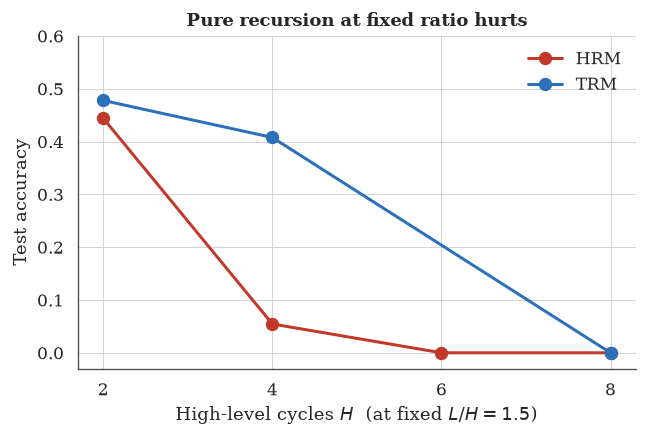

In [11]:
# Fixed-ratio scaling. Hold L/H = 1.5 and increase recurrence depth (H) for HRM and TRM.
fixed = abl[np.isclose(abl["ratio"], 1.5)].sort_values(["family", "H"])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for fam, color in [("HRM", ACCENT), ("TRM", TRM_COLOR)]:
    sub = fixed[fixed["family"] == fam]
    ax.plot(sub["H"], sub["accuracy"], marker="o", markersize=7, linewidth=1.8,
            color=color, label=fam)

ax.set_xlabel("High-level cycles $H$  (at fixed $L/H = 1.5$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.6)
ax.set_xticks(sorted(fixed["H"].unique()))
ax.set_title("Pure recursion at fixed ratio hurts")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_fixed_ratio")
plt.show()


### RQ2.1 (continued) — The full $(H, L)$ grid

The two sweeps above each hold one quantity fixed ($H \times L = 12$, or $L/H = 1.5$),
which makes the ratio and the total recurrence depth inseparable: at fixed depth $D$ the
ratio is forced to $L/H = D/H^2$, and at fixed ratio $r$ the depth is forced to
$H \times L = r H^2$. A single degree of freedom therefore drives both curves.

The heatmap below drops that constraint and reports accuracy for every measured
$(H, L)$ cell, so the high-level and low-level cycle counts can be read as independent
factors. Iso-ratio lines run diagonally (outlined cells are $L/H = 1$); iso-depth lines
are hyperbolas. Grey cells were not run.


In [12]:
# Shared axes across both families so the two panels are cell-for-cell comparable.
H_VALS = sorted(abl_grid["H"].unique())
L_VALS = sorted(abl_grid["L"].unique())


def hl_grid(family, values="accuracy"):
    return (
        abl_grid[abl_grid["family"] == family]
        .pivot_table(index="H", columns="L", values=values, aggfunc="mean")
        .reindex(index=H_VALS, columns=L_VALS)
    )


hrm_grid, trm_grid = hl_grid("HRM"), hl_grid("TRM")
pd.concat({"HRM": hrm_grid, "TRM": trm_grid}, names=["family"]).round(3)


L            1      2      3      4      6    9      12     24
family H                                                      
HRM    1  0.514    NaN  0.504    NaN  0.535  NaN  0.514  0.519
       2  0.449    NaN  0.444    NaN  0.439  NaN  0.405  0.436
       3    NaN    NaN  0.439  0.400  0.400  NaN  0.447    NaN
       4  0.374    NaN  0.062    NaN  0.055  NaN  0.000    NaN
       5    NaN    NaN    NaN    NaN  0.000  NaN    NaN    NaN
       6    NaN  0.000  0.000    NaN  0.000  0.0  0.000    NaN
       8    NaN    NaN    NaN    NaN    NaN  NaN  0.000    NaN
TRM    1  0.512    NaN  0.501    NaN  0.504  NaN  0.509  0.525
       2  0.535    NaN  0.478    NaN  0.465  NaN  0.486  0.462
       3    NaN    NaN  0.392  0.395  0.397  NaN  0.416    NaN
       4  0.449    NaN  0.395    NaN  0.408  NaN  0.400    NaN
       5    NaN    NaN    NaN    NaN  0.314  NaN    NaN    NaN
       6    NaN  0.377  0.000    NaN  0.000  0.0  0.338    NaN
       8    NaN    NaN    NaN    NaN    NaN  NaN  0.000    NaN

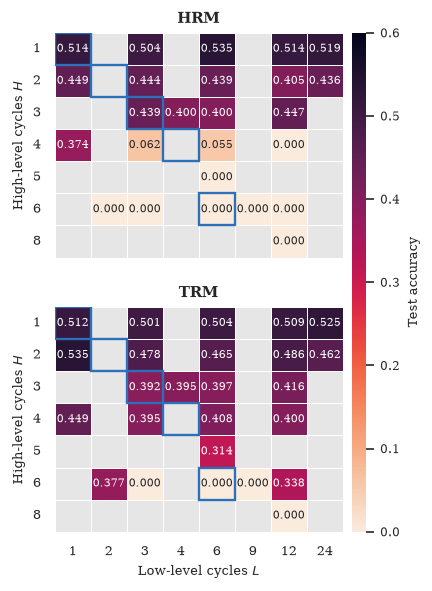

In [13]:
# Single-column figure: accuracy over the (H, L) grid, HRM above TRM on the same cell
# geometry, with one colorbar spanning both panels so they stay cell-for-cell aligned.
# No `sharex`: seaborn rewrites the tick labels per axes, which a shared axis drops.
def plot_hl_heatmaps(fname="ablation_hl_grid"):
    vmax = np.ceil(abl_grid["accuracy"].max() * 10) / 10
    fig = plt.figure(figsize=(COL_W, 5.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.05], hspace=0.22, wspace=0.06)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    cbar_ax = fig.add_subplot(gs[:, 1])

    for ax, (fam, grid) in zip(axes, [("HRM", hrm_grid), ("TRM", trm_grid)]):
        last = fam == "TRM"
        sns.heatmap(
            grid, ax=ax, mask=grid.isna(), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=vmax, linewidths=0.4, linecolor="white",
            annot_kws={"fontsize": 6.5}, cbar=last, cbar_ax=cbar_ax if last else None,
            cbar_kws={"label": "Test accuracy"} if last else None,
        )
        ax.set_facecolor("0.90")  # cells with no run
        ax.grid(False)

        # Outline the L/H = 1 diagonal: cells above it are high-level dominated.
        for i, h in enumerate(H_VALS):
            if h in L_VALS:
                ax.add_patch(mpl.patches.Rectangle(
                    (L_VALS.index(h), i), 1, 1, fill=False,
                    edgecolor=TRM_COLOR, linewidth=1.4, zorder=4,
                ))

        ax.set_title(fam, fontsize=9)
        ax.set_xticklabels(L_VALS if last else [], rotation=0, fontsize=7.5)
        ax.set_xlabel("Low-level cycles $L$" if last else "", fontsize=8)
        ax.set_yticklabels(H_VALS, rotation=0, fontsize=7.5)
        ax.set_ylabel("High-level cycles $H$", fontsize=8)
        if not last:
            ax.tick_params(axis="x", length=0)

    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_hl_heatmaps()

## RQ2.1' — Is backprop truncation the bottleneck?

RQ2.1 shows accuracy collapsing once the number of high-level cycles grows. A natural
suspect is HRM's **truncated BPTT**: after a short warmup, only the last 5 block applications
are differentiated ($H_{bp} = \min(H, 4)$ H steps and $L_{bp} = 5 - H_{bp}$ L steps, counted across
all H cycles), the earlier ones being run under `no_grad`, so the deeper the recursion the larger
the fraction of the computation that receives no learning signal.

To test this we re-ran the $L = 6$ column of the grid with **full backpropagation through
time** — gradients flow through every $H \times L$ cycle — and compared it against the
truncated-gradient runs at the same $(H, L)$.

**Answer: no.** Full BP is worth a couple of points where the model already works ($H = 2$),
but it does not move the collapse at all: at $H = 4$ and $H = 6$ the fully-differentiated
model is at or below the truncated one. The failure at high recursion depth is therefore a
property of the recurrent regime itself, not an artifact of the gradient approximation.


In [14]:
# Full-BP sweep: a plain W&B export (no doubled quoting), one run per (H, L) config.
fullbp = (
    pd.read_csv(RESULTS_DIR / "graphqa-full-bp.csv")
    .rename(columns={"H_cycles": "H", "L_cycles": "L", "eval/accuracy": "accuracy"})
    .loc[:, ["H", "L", "accuracy"]]
    .astype({"H": int, "L": int, "accuracy": float})
    .assign(bp=FULL_BP)
)

# Matching truncated-gradient HRM runs: the full-BP sweep only covers one L column.
L_FIXED = fullbp["L"].unique().item()
trunc = (
    abl.loc[(abl["family"] == "HRM") & (abl["L"] == L_FIXED), ["H", "L", "accuracy"]]
    .assign(bp=TRUNC_BP)
)

bp = pd.concat([trunc, fullbp], ignore_index=True).sort_values(["bp", "H"])
bp_grid = bp.pivot(index="H", columns="bp", values="accuracy")[[TRUNC_BP, FULL_BP]]
bp_grid["delta"] = bp_grid[FULL_BP] - bp_grid[TRUNC_BP]
bp_grid.round(3)


bp,Truncated BPTT (5 blocks),Full backprop,delta
H,,,
2,0.439,0.481,0.042
3,NaN,0.442,NaN
4,0.055,0.016,-0.039
6,NaN,0.000,NaN


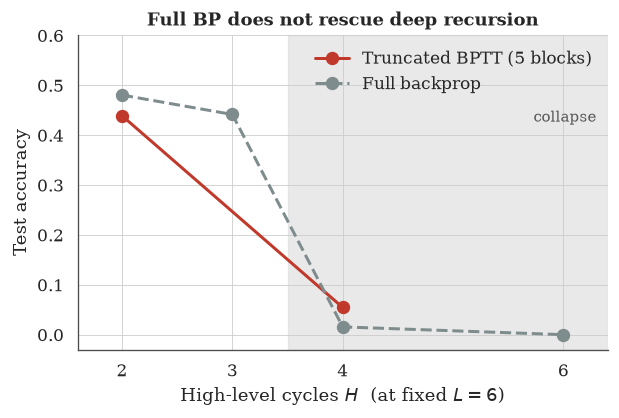

In [15]:
# Single-column figure: accuracy vs. recursion depth at fixed L, one line per gradient
# regime. The truncated sweep covers fewer H values, so the lines are plotted per-regime.
def plot_bp_truncation(fname="ablation_full_bp"):
    h_vals = sorted(bp["H"].unique())
    fig, ax = plt.subplots(figsize=(COL_W * 1.7, 3.4))

    # Depths at which the truncated model has already collapsed.
    ax.axvspan(3.5, h_vals[-1] + 0.4, color="0.88", alpha=0.7, zorder=0)
    ax.text(h_vals[-1] + 0.3, 0.45, "collapse", fontsize=9, color="0.35",
            ha="right", va="top")

    for regime, color, style in [(TRUNC_BP, ACCENT, "-"), (FULL_BP, MUTED, "--")]:
        sub = bp[bp["bp"] == regime].sort_values("H")
        ax.plot(sub["H"], sub["accuracy"], style, marker="o", markersize=7,
                linewidth=1.8, color=color, label=regime, zorder=3)

    ax.set_xticks(h_vals)
    ax.set_xlim(h_vals[0] - 0.4, h_vals[-1] + 0.4)
    ax.set_ylim(-0.03, 0.6)
    ax.set_xlabel(f"High-level cycles $H$  (at fixed $L = {L_FIXED}$)")
    ax.set_ylabel("Test accuracy")
    ax.set_title("Full BP does not rescue deep recursion")
    ax.legend(title="")
    sns.despine(ax=ax)
    save_fig(fig, fname)
    plt.show()


plot_bp_truncation()


## RQ2.2 — Does the recursion effect vary across classes of tasks?

RQ2.1 measures the recursion regime on GraphQA alone, where every task is a graph query.
RQ2.2 asks whether the optimal — or even the viable — recursion regime is a property of the
*model* or of the *task class*: a task family that needs long chained deduction may reward
depth that a lookup-style family does not.

Every benchmark below re-runs the HRM half of the RQ2.1 sweep: the same 300M-parameter
HRM, trained from scratch per $(H, L)$ configuration (truncated BPTT, 5-block budget). The configuration
sets only partly overlap across benchmarks, and a few runs were trained but never evaluated;
both gaps are shown explicitly rather than imputed.

The three **MetaQA Gold-$k$** sweeps are used twice: in RQ2.1.1 as KGQA benchmarks next to
GraphQA, KQA-Pro and GSM8K, and in RQ2.1.2 as the controlled I/O-shape contrast (identical
context, output set of $k$ entities).

### RQ2.1.1 — Does it vary over the type of task (KGQA, general knowledge, math, …)?

Three task types: **graph reasoning** (GraphQA), **KGQA** (MetaQA Gold-1/5/10 and
Retrieved-1, KQA-Pro) and **math** (GSM8K). Each benchmark is scored with its primary metric —
exact match for GraphQA and KQA-Pro, answer-set F1 for MetaQA (equal to exact match when
$k = 1$), accuracy for GSM8K — and, because raw scales differ by 20×, compared *relative to
its own best configuration*. General knowledge (MMLU) and MATH were not run.

**Answer: the regime that works does not depend on the task type; only how fast
performance decays before the collapse does.**

1. **$H = 1$ is best everywhere.** Every benchmark peaks at a single high-level cycle, and
   no task type rewards additional high-level recursion.
2. **The collapse is task-independent.** From $H = 4$ onward every benchmark is at or near
   zero (GraphQA ≤ 0.06, KQA-Pro ≤ 0.006, GSM8K 0 with every answer unparseable, MetaQA
   Gold-1 0 at $H = 5$) — the same boundary as in RQ2.1, so it belongs to the model.
3. **The decay before the collapse is task-dependent.** Graph reasoning degrades gently
   (GraphQA keeps 86% of its best score at $H = 2$ and 78% at $H = 3$), whereas KGQA
   lookups lose more than half at $H = 2$ (KQA-Pro 46%, MetaQA Gold-1 43%). Retrieved-1
   decays less, but its ceiling is set by retrieval quality (0.105), not reasoning.
4. **KGQA needs no recursion at all.** On MetaQA, $(H, L) = (1, 1)$ — a single cycle — is
   within 0.03 of the best configuration on every variant.

GSM8K is at the floor (≤ 2.5%) for every configuration: a 300M model trained from scratch
does not learn grade-school math, so its relative curve says little beyond the collapse at
$H \ge 4$.

In [16]:
# Per-benchmark recursion sweeps: HRM (300M, trained from scratch) at a set of (H, L)
# configurations, one W&B export for training and one for evaluation per benchmark.
# A run can be trained but never evaluated (empty eval metrics, or no eval row at all);
# those cells are kept apart from configurations that were simply never trained.
VARIANTS_DIR = RESULTS_DIR / "variants"

# (display name, task type, file stem, primary metric). MetaQA answers are sets, so its
# primary metric is answer-set F1 as in RQ3 (identical to exact match when k = 1).
SWEEP_SOURCES = [
    ("MetaQA Gold-1", "KGQA", "metaqa-gold1", "eval/f1"),
    ("MetaQA Gold-5", "KGQA", "metaqa-gold5", "eval/f1"),
    ("MetaQA Gold-10", "KGQA", "metaqa-gold10", "eval/f1"),
    ("MetaQA Retrieved-1", "KGQA", "metaqa-retrieved1", "eval/f1"),
    ("KQA-Pro", "KGQA", "kqapro", "eval/accuracy"),
    ("GSM8K", "Math", "gsm8k", "eval/GSM8k/acc"),
]
GRAPHQA = "GraphQA"
TASK_TYPES = {GRAPHQA: "Graph reasoning", **{n: t for n, t, _, _ in SWEEP_SOURCES}}
SWEEP_ORDER = list(TASK_TYPES)


def load_sweep(name, stem, metric):
    train = (
        pd.read_csv(VARIANTS_DIR / f"{stem}-ablation-train.csv")
        .rename(columns={"arch.H_cycles": "H", "arch.L_cycles": "L",
                         "train/accuracy": "train_acc"})
        .reindex(columns=["H", "L", "train_acc"])
    )
    evals = (
        pd.read_csv(VARIANTS_DIR / f"{stem}-ablation-eval.csv")
        .rename(columns={"H_cycles": "H", "L_cycles": "L", metric: "score"})
        .sort_values("Created")
        .drop_duplicates(subset=["H", "L"], keep="last")
    )
    # Whole-answer-set exact match and hits@1 exist for MetaQA only.
    evals["em"] = evals.get("eval/accuracy", evals["score"])
    evals["hits1"] = evals.get("eval/hits_at_1", np.nan)
    out = train.merge(evals[["H", "L", "score", "em", "hits1"]], on=["H", "L"], how="left")
    return out.assign(task=name).astype({"H": int, "L": int})


# GraphQA is the HRM half of the RQ2.1 grid (eval accuracy is exact match).
graphqa_sweep = (
    abl.loc[abl["family"] == "HRM", ["H", "L", "accuracy"]]
    .rename(columns={"accuracy": "score"})
    .assign(em=lambda d: d["score"], hits1=np.nan, train_acc=np.nan, task=GRAPHQA)
)
sweeps = pd.concat(
    [graphqa_sweep] + [load_sweep(n, s, m) for n, _, s, m in SWEEP_SOURCES],
    ignore_index=True,
)
sweeps["type"] = sweeps["task"].map(TASK_TYPES)
sweeps["evaluated"] = sweeps["score"].notna()
# Normalise by each task's best configuration: raw scales differ by 20x across benchmarks.
sweeps["rel"] = sweeps["score"] / sweeps.groupby("task")["score"].transform("max")

# Union of every trained configuration, ordered by H then L.
SWEEP_CONFIGS = sorted(set(zip(sweeps["H"], sweeps["L"])))
sweep_grid = (
    sweeps.pivot(index="task", columns=["H", "L"], values="score")
    .reindex(index=SWEEP_ORDER, columns=pd.MultiIndex.from_tuples(SWEEP_CONFIGS))
)
trained_grid = (
    sweeps.assign(trained=True)
    .pivot(index="task", columns=["H", "L"], values="trained")
    .reindex(index=SWEEP_ORDER, columns=sweep_grid.columns)
    .notna()
)

print(f"{len(sweeps)} trained runs, {sweeps['evaluated'].sum()} evaluated, "
      f"{len(SWEEP_CONFIGS)} distinct (H, L) configurations")
sweep_grid.round(3)

51 trained runs, 37 evaluated, 15 distinct (H, L) configurations


1                    2                    3         \
                       1      6      12     3      6      12     4      6    
task                                                                         
GraphQA               NaN    NaN  0.514  0.444  0.439    NaN  0.400    NaN   
MetaQA Gold-1       0.370  0.400    NaN    NaN    NaN  0.172    NaN  0.138   
MetaQA Gold-5       0.192  0.192    NaN    NaN    NaN  0.124    NaN  0.119   
MetaQA Gold-10      0.379  0.383    NaN    NaN    NaN    NaN    NaN    NaN   
MetaQA Retrieved-1  0.105  0.082    NaN    NaN    NaN  0.094    NaN  0.065   
KQA-Pro               NaN    NaN  0.202  0.084  0.093    NaN  0.068    NaN   
GSM8K                 NaN    NaN  0.025  0.019  0.020    NaN  0.023    NaN   

                        4           5    6             8  
                       3      6    6    2   6    9    12  
task                                                      
GraphQA             0.062  0.055  NaN  0.0 NaN  0.0  0.0  
MetaQA Gold-1         NaN    NaN  0.0  NaN NaN  NaN  NaN  
MetaQA Gold-5         NaN    NaN  NaN  NaN NaN  NaN  NaN  
MetaQA Gold-10        NaN    NaN  NaN  NaN NaN  NaN  NaN  
MetaQA Retrieved-1    NaN    NaN  NaN  NaN NaN  NaN  NaN  
KQA-Pro             0.006  0.000  NaN  NaN NaN  0.0  NaN  
GSM8K               0.000    NaN  NaN  0.0 NaN  NaN  NaN

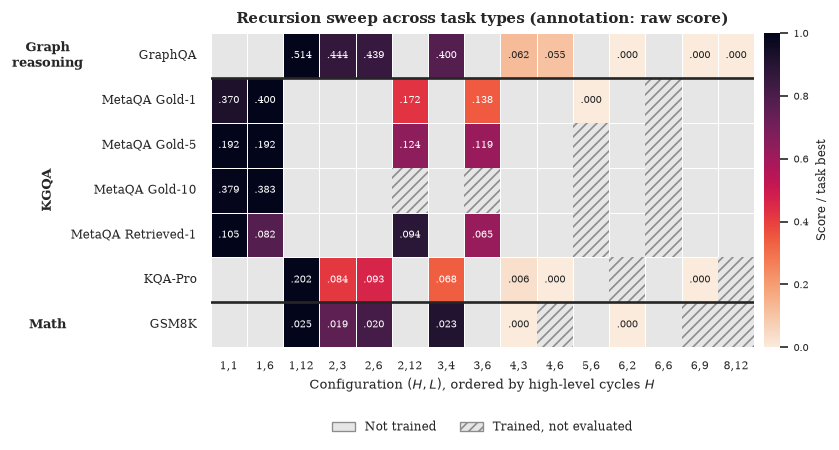

In [17]:
# Full-width `figure*`: every benchmark x every (H, L) configuration. Color is the score
# relative to that benchmark's best configuration, so rows with very different raw scales
# (GraphQA ~0.5, GSM8K ~0.02) share one scale; the annotation is the raw score.
def fmt_score(v):
    return f"{v:.3f}".lstrip("0") if v < 1 else f"{v:.2f}"


def plot_sweep_heatmap(fname="recursion_by_task"):
    labels = [f"{h},{l}" for h, l in SWEEP_CONFIGS]
    raw = sweep_grid.set_axis(labels, axis=1)
    rel = raw.div(raw.max(axis=1), axis=0)
    annot = raw.map(lambda v: "" if pd.isna(v) else fmt_score(v))

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.3 * len(SWEEP_ORDER) + 1.3))
    sns.heatmap(
        rel, mask=rel.isna(), annot=annot, fmt="",
        cmap="rocket_r", vmin=0, vmax=1, linewidths=0.4, linecolor="white",
        annot_kws={"fontsize": 6}, cbar_kws={"label": "Score / task best", "pad": 0.015},
        ax=ax,
    )
    ax.set_facecolor("0.90")  # configuration never trained on this benchmark
    ax.grid(False)

    # Trained but never evaluated: hatched, so it is not mistaken for an untried config.
    for i, task in enumerate(SWEEP_ORDER):
        for j, cfg in enumerate(SWEEP_CONFIGS):
            if trained_grid.loc[task, cfg] and pd.isna(sweep_grid.loc[task, cfg]):
                ax.add_patch(mpl.patches.Rectangle(
                    (j, i), 1, 1, facecolor="0.90", edgecolor="0.55", hatch="////",
                    linewidth=0, zorder=3,
                ))

    # Task-type blocks, separated like the Direct / Meta-ICL blocks of RQ1.
    types = [TASK_TYPES[t] for t in SWEEP_ORDER]
    bounds = [i for i in range(1, len(types)) if types[i] != types[i - 1]]
    for b in bounds:
        ax.axhline(b, color="0.15", linewidth=1.6, zorder=5)
    for name, lo, hi in zip(dict.fromkeys(types), [0] + bounds, bounds + [len(types)]):
        ax.text(-0.3, (lo + hi) / 2, name.replace(" ", "\n"),
                transform=ax.get_yaxis_transform(), rotation=90 if hi - lo > 1 else 0,
                va="center", ha="center", fontsize=7.5, fontweight="bold")

    ax.set_xticklabels(labels, rotation=0, fontsize=6.5)
    ax.set_yticklabels(SWEEP_ORDER, rotation=0, fontsize=7)
    ax.set_xlabel("Configuration $(H, L)$, ordered by high-level cycles $H$", fontsize=8)
    ax.set_ylabel("")
    ax.set_title("Recursion sweep across task types (annotation: raw score)", fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)

    handles = [
        mpl.patches.Patch(facecolor="0.90", edgecolor="0.55", label="Not trained"),
        mpl.patches.Patch(facecolor="0.90", edgecolor="0.55", hatch="////",
                          label="Trained, not evaluated"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.2),
              ncol=2, fontsize=7, frameon=False)
    save_fig(fig, fname)
    plt.show()


plot_sweep_heatmap()

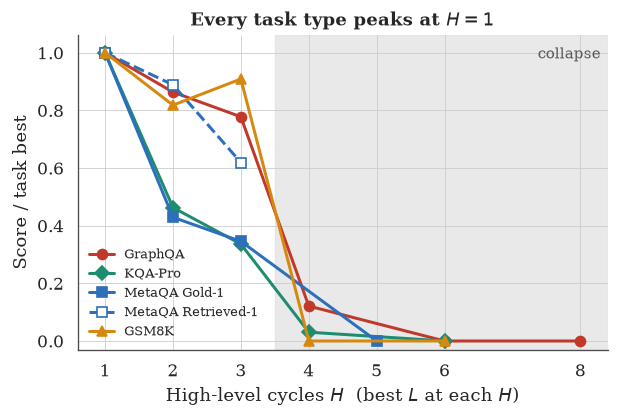

In [18]:
# Single-column-and-a-half figure: best score over L at each H, relative to the task's best.
# Gold-5 / Gold-10 are left to RQ2.1.2, where output cardinality is the variable.
TASK_STYLE = {
    GRAPHQA: dict(color=ACCENT, marker="o", linestyle="-"),
    "KQA-Pro": dict(color="#1e8c6e", marker="D", linestyle="-"),
    "MetaQA Gold-1": dict(color=TRM_COLOR, marker="s", linestyle="-"),
    "MetaQA Retrieved-1": dict(color=TRM_COLOR, marker="s", linestyle="--",
                               markerfacecolor="white"),
    "GSM8K": dict(color="#d68910", marker="^", linestyle="-"),
}


def plot_sweep_by_h(fname="recursion_by_task_h"):
    best_h = (
        sweeps[sweeps["evaluated"]].groupby(["task", "H"], as_index=False)["rel"].max()
    )
    h_vals = sorted(best_h["H"].unique())
    fig, ax = plt.subplots(figsize=(COL_W * 1.7, 3.4))

    # High-level depths at which every benchmark has collapsed.
    ax.axvspan(3.5, h_vals[-1] + 0.4, color="0.88", alpha=0.7, zorder=0)
    ax.text(h_vals[-1] + 0.3, 1.02, "collapse", fontsize=9, color="0.35",
            ha="right", va="top")

    for task, style in TASK_STYLE.items():
        sub = best_h[best_h["task"] == task].sort_values("H")
        ax.plot(sub["H"], sub["rel"], markersize=6, linewidth=1.8, label=task,
                zorder=3, **style)

    ax.set_xticks(h_vals)
    ax.set_xlim(h_vals[0] - 0.4, h_vals[-1] + 0.4)
    ax.set_ylim(-0.03, 1.06)
    ax.set_xlabel("High-level cycles $H$  (best $L$ at each $H$)")
    ax.set_ylabel("Score / task best")
    ax.set_title("Every task type peaks at $H = 1$")
    ax.legend(title="", fontsize=7.5, loc="lower left")
    sns.despine(ax=ax)
    save_fig(fig, fname)
    plt.show()


plot_sweep_by_h()

In [19]:
# Full-width `table*`: raw score per (benchmark, configuration), the best cell of each row
# in bold. `--` = not trained, `n/e` = trained but not evaluated.
def sweep_table_latex(caption, label):
    cells = pd.DataFrame("--", index=SWEEP_ORDER, columns=sweep_grid.columns)
    for task in SWEEP_ORDER:
        best = sweep_grid.loc[task].max()
        for cfg in SWEEP_CONFIGS:
            v = sweep_grid.loc[task, cfg]
            if pd.notna(v):
                cells.loc[task, cfg] = rf"\textbf{{{fmt_score(v)}}}" if v == best else fmt_score(v)
            elif trained_grid.loc[task, cfg]:
                cells.loc[task, cfg] = "n/e"
    cells.columns = [f"{h},{l}" for h, l in SWEEP_CONFIGS]
    cells.insert(0, "Type", [TASK_TYPES[t] for t in SWEEP_ORDER])
    lines = cells.to_latex(column_format="ll|" + "c" * len(SWEEP_CONFIGS),
                           escape=False).splitlines()
    head = lines.index(r"\midrule")
    lines[head - 1] = r"Benchmark & Type & " + " & ".join(
        rf"\rotatebox{{90}}{{{c}}}" for c in cells.columns[1:]) + r" \\"
    return "\n".join([
        r"\begin{table*}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%", *lines, r"}", r"\end{table*}",
    ])


print(sweep_table_latex(
    "HRM test score over the $(H, L)$ recursion sweep, per benchmark. Columns are "
    "$(H, L)$ configurations. Primary metric: exact match (GraphQA, KQA-Pro), answer-set "
    "F1 (MetaQA), accuracy (GSM8K). Best configuration per benchmark in bold. "
    "\\texttt{--}: configuration not trained; n/e: trained but not evaluated.",
    "tab:recursion_by_task",
))

\begin{table*}[t]
\centering
\small
\caption{HRM test score over the $(H, L)$ recursion sweep, per benchmark. Columns are $(H, L)$ configurations. Primary metric: exact match (GraphQA, KQA-Pro), answer-set F1 (MetaQA), accuracy (GSM8K). Best configuration per benchmark in bold. \texttt{--}: configuration not trained; n/e: trained but not evaluated.}
\label{tab:recursion_by_task}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll|ccccccccccccccc}
\toprule
Benchmark & Type & \rotatebox{90}{1,1} & \rotatebox{90}{1,6} & \rotatebox{90}{1,12} & \rotatebox{90}{2,3} & \rotatebox{90}{2,6} & \rotatebox{90}{2,12} & \rotatebox{90}{3,4} & \rotatebox{90}{3,6} & \rotatebox{90}{4,3} & \rotatebox{90}{4,6} & \rotatebox{90}{5,6} & \rotatebox{90}{6,2} & \rotatebox{90}{6,6} & \rotatebox{90}{6,9} & \rotatebox{90}{8,12} \\
\midrule
GraphQA & Graph reasoning & -- & -- & \textbf{.514} & .444 & .439 & -- & .400 & -- & .062 & .055 & -- & .000 & -- & .000 & .000 \\
MetaQA Gold-1 & KGQA & .370 & \textbf{.400} & -- & -

### RQ2.1.2 — Does it vary over the I/O shape of the task?

The MetaQA **Gold-$k$** sweeps fix the input — a gold subgraph of ~80 triples — and vary
only the output: a set of exactly $k \in \{1, 5, 10\}$ entities. This contrasts
*short reasoning → one-entity answer* with *the same reasoning → a long, structured list*,
and so isolates whether the recurrent cycles serve internal deliberation or output
construction. Answer-set F1 gives partial credit per entity; exact match needs the whole set.

**Answer: the output shape moves the score level, not the recursion optimum.**

1. **Same optimum for every $k$.** $H = 1$ is best for Gold-1, Gold-5 and Gold-10, and
   within $H = 1$ the low-level depth is irrelevant ($L = 1$ vs. $L = 6$ differ by
   ≤ 0.03 F1). Longer outputs do not make extra cycles useful.
2. **Longer outputs lose the whole set, not the entities.** At $H = 1$, F1 is similar for
   $k = 1$ and $k = 10$ (~0.38–0.40), but exact match falls from 0.40 to ≤ 0.09, and Gold-5
   sits lower on both (F1 0.19, EM 0.02).
3. **Deeper recursion hurts every shape; the multi-answer case keeps more partial credit.**
   At $H = 2, 3$ Gold-1 keeps 35–43% of its best F1 and Gold-5 62–64%, but Gold-5 exact
   match drops to 0.
4. **The missing evaluations are collapsed runs.** Gold-10 was evaluated at $H = 1$ only.
   The final training token accuracy (bottom panel, last logged batch, so noisy) shows that
   every unevaluated run with $H \ge 3$ ended training at ≤ 0.37, against ≥ 0.96 for every
   $H = 1$ run, i.e. these runs had already collapsed in training. Gold-10 at $(2, 12)$ is
   the exception (0.95 train accuracy), so its missing evaluation is a real gap. In the
   test panels every unevaluated run is plotted at 0; the table keeps them as n/e.

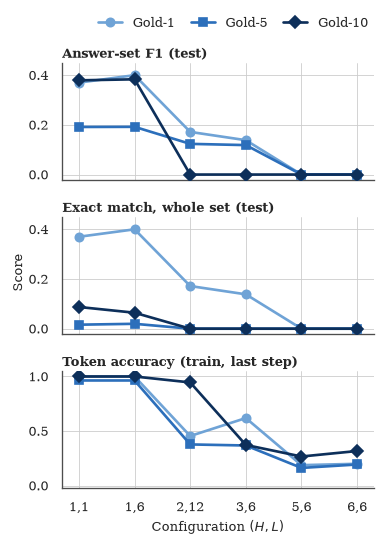

In [20]:
# RQ2.1.2 reuses the MetaQA Gold-k sweeps: identical ~80-triple gold context, output set of
# exactly k entities. k orders the series, so they take one hue, light -> dark.
GOLD_K = {"MetaQA Gold-1": 1, "MetaQA Gold-5": 5, "MetaQA Gold-10": 10}
GOLD_STYLE = {
    1: dict(color="#6fa3d6", marker="o"),
    5: dict(color=TRM_COLOR, marker="s"),
    10: dict(color="#0d2f5a", marker="D"),
}
gold = sweeps[sweeps["task"].isin(GOLD_K)].assign(k=lambda d: d["task"].map(GOLD_K))
# In the figure, runs that were trained but never evaluated are plotted at a test score of
# 0 (collapsed); the LaTeX table below keeps them as n/e.
gold_plot = gold.assign(score=gold["score"].fillna(0.0), em=gold["em"].fillna(0.0))
GOLD_CONFIGS = sorted(set(zip(gold["H"], gold["L"])))


# Single-column figure: the three metrics are stacked on a shared configuration axis so
# the figure keeps paper-size fonts at \columnwidth. Test metrics on top, training below.
def plot_io_shape(fname="recursion_io_shape"):
    x = {cfg: i for i, cfg in enumerate(GOLD_CONFIGS)}
    fig, axes = plt.subplots(
        3, 1, figsize=(COL_W, 4.6), sharex=True, gridspec_kw={"hspace": 0.32},
    )
    panels = [
        (axes[0], "score", "Answer-set F1 (test)", 0.45, [0, 0.2, 0.4]),
        (axes[1], "em", "Exact match, whole set (test)", 0.45, [0, 0.2, 0.4]),
        (axes[2], "train_acc", "Token accuracy (train, last step)", 1.05, [0, 0.5, 1.0]),
    ]
    for ax, col, title, top, ticks in panels:
        for k, style in GOLD_STYLE.items():
            sub = gold_plot[gold_plot["k"] == k].sort_values(["H", "L"])
            ax.plot([x[c] for c in zip(sub["H"], sub["L"])], sub[col], markersize=5,
                    linewidth=1.6, label=f"Gold-{k}", zorder=3, **style)
        ax.set_title(title, loc="left", fontsize=8, pad=3)
        ax.set_ylim(-0.02, top)
        ax.set_yticks(ticks)
        ax.tick_params(labelsize=7.5)

    axes[-1].set_xticks(range(len(GOLD_CONFIGS)))
    axes[-1].set_xticklabels([f"{h},{l}" for h, l in GOLD_CONFIGS])
    axes[-1].set_xlim(-0.3, len(GOLD_CONFIGS) - 0.7)
    axes[-1].set_xlabel("Configuration $(H, L)$", fontsize=8)
    fig.supylabel("Score", fontsize=8, x=0.0)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.55, 0.985),
               ncol=3, fontsize=8, frameon=False, handlelength=1.8, columnspacing=1.2)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_io_shape()


In [21]:
io_table = pd.concat(
    {f"Gold-{k}": gold[gold["k"] == k].set_index(["H", "L"])[["score", "em", "hits1"]]
     .set_axis(["F1", "EM", "Hits@1"], axis=1) for k in GOLD_K.values()},
    axis=1,
).reindex(GOLD_CONFIGS)
io_table.index = [f"$H{h}, L{l}$" for h, l in GOLD_CONFIGS]
# Hits@1 equals F1 and EM when every question has a single answer.
io_table = io_table.drop(columns=[("Gold-1", "EM"), ("Gold-1", "Hits@1")])

io_lines = bold_best(io_table, "{:.3f}".format, 3, na_rep="n/e").to_latex(
    column_format="l|c|ccc|ccc", escape=False, multicolumn=True, multicolumn_format="c",
).splitlines()
print("\n".join([
    r"\begin{table}[t]", r"\centering", r"\small",
    r"\caption{MetaQA Gold-$k$ over the recursion sweep: fixed gold context, output set "
    r"of exactly $k$ entities. For $k = 1$, F1, exact match and Hits@1 coincide. "
    r"Best configuration per column in bold. n/e: trained but not evaluated.}",
    r"\label{tab:recursion_io_shape}",
    r"\resizebox{\columnwidth}{!}{%", *io_lines, r"}",
    r"\end{table}",
]))
io_table.round(3)

\begin{table}[t]
\centering
\small
\caption{MetaQA Gold-$k$ over the recursion sweep: fixed gold context, output set of exactly $k$ entities. For $k = 1$, F1, exact match and Hits@1 coincide. Best configuration per column in bold. n/e: trained but not evaluated.}
\label{tab:recursion_io_shape}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{l|c|ccc|ccc}
\toprule
 & Gold-1 & \multicolumn{3}{c}{Gold-5} & \multicolumn{3}{c}{Gold-10} \\
 & F1 & F1 & EM & Hits@1 & F1 & EM & Hits@1 \\
\midrule
$H1, L1$ & 0.370 & \textbf{0.192} & 0.016 & 0.229 & 0.379 & \textbf{0.087} & 0.326 \\
$H1, L6$ & \textbf{0.400} & \textbf{0.192} & \textbf{0.020} & \textbf{0.236} & \textbf{0.383} & 0.064 & \textbf{0.357} \\
$H2, L12$ & 0.172 & 0.124 & 0.000 & 0.177 & n/e & n/e & n/e \\
$H3, L6$ & 0.138 & 0.119 & 0.000 & 0.120 & n/e & n/e & n/e \\
$H5, L6$ & 0.000 & n/e & n/e & n/e & n/e & n/e & n/e \\
$H6, L6$ & n/e & n/e & n/e & n/e & n/e & n/e & n/e \\
\bottomrule
\end{tabular}
}
\end{table}


Gold-1 Gold-5               Gold-10              
              F1     F1     EM Hits@1      F1     EM Hits@1
$H1, L1$   0.370  0.192  0.016  0.229   0.379  0.087  0.326
$H1, L6$   0.400  0.192  0.020  0.236   0.383  0.064  0.357
$H2, L12$  0.172  0.124  0.000  0.177     NaN    NaN    NaN
$H3, L6$   0.138  0.119  0.000  0.120     NaN    NaN    NaN
$H5, L6$   0.000    NaN    NaN    NaN     NaN    NaN    NaN
$H6, L6$     NaN    NaN    NaN    NaN     NaN    NaN    NaN

# RQ3 — Real knowledge-graph QA: MetaQA and KQA-Pro

GraphQA is synthetic. RQ3 asks whether the same picture holds on two established KGQA
benchmarks, where the model must read a linearized set of `(s, p, o)` triples and answer a
natural-language question.

**MetaQA** is evaluated under four context conditions. *Gold-$k$* supplies a gold subgraph of
~80 triples and keeps only questions whose gold answer set has exactly $k$ elements
($k \in \{1, 5, 10\}$), so it sweeps **answer-set cardinality** at fixed context size.
*Retrieved-1* keeps single-answer questions but replaces the gold subgraph with a
**retrieved** one, so it is the realistic counterpart of Gold-1. Because answers are sets, we
report both answer-set **F1** (partial credit) and **exact match** (the full set must be
right); the gap between them is what answer cardinality costs.

**KQA-Pro** is a single split annotated with seven **question types** (Basic, Comparison,
Count, Logical, Multihop, Qualifier, Verify), which isolates *which kind* of reasoning each
model can do. Every panel carries the random-answer control, since Verify is binary and
Count has a small label set — both are far from 0 by chance.

All RQ3 runs use the standard-SFT regime; no Meta-ICL or OOD sweep was run on these
benchmarks.
HRM-Text-1B, DFM-Mimir, Ouro-1.4B, Qwen2.5-3B, Qwen3-4B and Mistral-7B are fine-tuned with
gradient-norm clipping at 1.0; the other baselines without clipping. HRM-Text-1B and DFM-Mimir are
also fine-tuned without clipping; the summary table reports both runs (Clip column), the figures and
appendix tables the clipped one. Clipping raises HRM-Text-1B by +3.7 points of mean MetaQA exact match
(0.691 → 0.728) and +0.9 of KQA-Pro exact match (0.697 → 0.707); unclipped runs: W&B `rlk96n0v`,
`4w5cdq6f`, `rfwf9gdk`, `kd2n2s52` (MetaQA), `yex154mm` (KQA-Pro, 2026-09-01). For DFM-Mimir,
clipping adds +0.8 points of MetaQA exact match (0.760 → 0.767) and +2.5 of KQA-Pro exact match
(0.693 → 0.718); unclipped runs: W&B `*-mimir-v1-id` (`fvfxlon3`, `s7d5x6yr`, `vrl6i7nm`, `s64i7mla`,
`9ok5kryt`; GRL `CLIP=0 CONFIG=mimir1 TAG=mimir-v1 scripts/run_hrm_clip1.sh`).
DFM-Mimir has the HRM-Text-1B architecture ($H2L3$, same stacks and hidden size 1536) with a
262k-token vocabulary (65k for HRM-Text-1B) and different pretraining; it is fine-tuned with exactly the HRM-Text-1B recipe (GRL
`scripts/run_hrm_clip1.sh`, W&B runs `*-mimir-v1-clip1-id`, added to the exports with
`scripts/pull_kgqa_runs.py`).


In [22]:
# Both KGQA benchmarks are plain W&B exports with one row per (model, context variant).
METAQA_VARIANTS = {
    "metaqa-gold-1": "Gold-1",
    "metaqa-gold-5": "Gold-5",
    "metaqa-gold-10": "Gold-10",
    "metaqa-retrieved-1": "Retrieved-1",
}
VARIANT_ORDER = list(METAQA_VARIANTS.values())
HOPS = ["1hop", "2hop", "3hop"]
KQA_TYPES = [
    "Basic", "Comparison", "Count", "Logical", "Multihop", "Qualifier", "Verify",
]
RANDOM_LABEL = "Random answer"


def load_kgqa(name):
    """Latest run per (arch, clipping, variant); `clipped` = gradient-norm clipping at 1.0."""
    df = pd.read_csv(RESULTS_DIR / f"{name}.csv")
    cfg = df["dataset"].map(ast.literal_eval)
    df["arch"] = df["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    df["variant"] = cfg.map(lambda d: METAQA_VARIANTS.get(d["name"], d["name"]))
    df["clipped"] = df["trainer"].map(lambda s: float(ast.literal_eval(s)["gradient_clip_val"]) > 0)
    return (
        df.sort_values("Created")
        .drop_duplicates(subset=["arch", "clipped", "variant"], keep="last")
        .reset_index(drop=True)
    )


def prefer_clipped(df):
    """One run per (arch, variant) for the figures and appendix tables: the clipped one if any."""
    return (
        df.sort_values(["clipped", "Created"])
        .drop_duplicates(subset=["arch", "variant"], keep="last")
        .reset_index(drop=True)
    )


def rank_archs(scores):
    """HRM-Text pinned first, every other architecture ranked by `scores`."""
    rest = scores.drop(index=HRM_ARCH, errors="ignore").sort_values(ascending=False)
    return [HRM_ARCH] + list(rest.index)


# HRM-Text-1B and DFM-Mimir have clipped and unclipped runs; both go to the summary table.
metaqa_all = load_kgqa("metaqa-variants")
kqapro_all = load_kgqa("kqa-pro")
metaqa = prefer_clipped(metaqa_all)
kqapro = prefer_clipped(kqapro_all).set_index("arch")


def metaqa_matrix(metric):
    return metaqa.pivot(index="arch", columns="variant", values=metric)[VARIANT_ORDER]


metaqa_f1 = metaqa_matrix("val/set_f1")
METAQA_ORDER = rank_archs(metaqa_f1.mean(axis=1))
metaqa_f1 = metaqa_f1.reindex(METAQA_ORDER)
metaqa_em = metaqa_matrix("val/exact_match").reindex(METAQA_ORDER)
# Strongest non-HRM architecture, highlighted in every RQ3 panel.
METAQA_BEST = metaqa_f1.drop(index=HRM_ARCH).mean(axis=1).idxmax()

# The random-answer control depends only on the variant, so one value per variant.
metaqa_random = (
    metaqa.groupby("variant")[[f"val/random_baseline_{h}" for h in HOPS]]
    .mean().mean(axis=1)[VARIANT_ORDER]
)

KQA_ORDER = rank_archs(kqapro["val/exact_match"])
kqa_by_type = kqapro[[f"val/exact_match_{t}" for t in KQA_TYPES]].reindex(KQA_ORDER)
kqa_by_type.columns = KQA_TYPES
kqa_random = kqapro[[f"val/random_baseline_{t}" for t in KQA_TYPES]]
assert (kqa_random.nunique() == 1).all(), "random control should not vary by model"
kqa_random = kqa_random.iloc[0].set_axis(KQA_TYPES)

assert len(metaqa) == len(METAQA_ORDER) * len(VARIANT_ORDER)
assert metaqa_f1.notna().all().all() and kqa_by_type.notna().all().all()
print(f"MetaQA: {len(METAQA_ORDER)} models x {len(VARIANT_ORDER)} variants   "
      f"KQA-Pro: {len(KQA_ORDER)} models   best MetaQA baseline: {METAQA_BEST}")
metaqa_f1.round(3)


MetaQA: 11 models x 4 variants   KQA-Pro: 10 models   best MetaQA baseline: Qwen3-4B


/tmp/ipykernel_513612/4159187264.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["arch"] = df["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
/tmp/ipykernel_513612/4159187264.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["variant"] = cfg.map(lambda d: METAQA_VARIANTS.get(d["name"], d["name"]))
/tmp/ipykernel_513612/4159187264.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

variant,Gold-1,Gold-5,Gold-10,Retrieved-1
arch,,,,
HRM-Text-1B,0.980,0.898,0.916,0.731
Qwen3-4B,0.987,0.938,0.922,0.766
DFM-Mimir,0.977,0.939,0.943,0.693
Ouro-1.4B,0.970,0.932,0.943,0.706
Qwen2.5-3B,0.977,0.906,0.886,0.695
Qwen2.5-1.5B,0.950,0.895,0.863,0.711
Llama-3.2-1B,0.935,0.868,0.873,0.688
Qwen3-0.6B,0.942,0.887,0.841,0.688
Gemma-3-1B,0.897,0.842,0.847,0.650


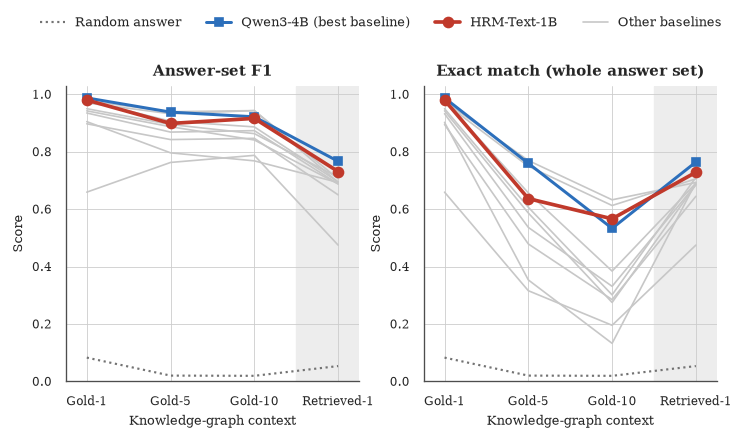

In [23]:
# Full-width `figure*`: MetaQA across the four context variants. Set F1 barely moves while
# exact match collapses, so the two panels use independent y-scales.
def plot_metaqa_context(fname="kgqa_metaqa_context"):
    x = np.arange(len(VARIANT_ORDER))
    fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, 3.2), gridspec_kw={"wspace": 0.22})

    panels = [
        (axes[0], metaqa_f1, "Answer-set F1"),
        (axes[1], metaqa_em, "Exact match (whole answer set)"),
    ]
    for ax, mat, title in panels:
        # Retrieved-1 swaps the gold subgraph for a retriever; it is Gold-1's counterpart.
        ax.axvspan(len(VARIANT_ORDER) - 1.5, len(VARIANT_ORDER) - 0.5,
                   color="0.93", zorder=0)
        for arch in mat.index.drop([HRM_ARCH, METAQA_BEST]):
            ax.plot(x, mat.loc[arch], color="0.78", linewidth=1.0, zorder=1)
        ax.plot(x, metaqa_random, color="0.45", linestyle=":", linewidth=1.3,
                label=RANDOM_LABEL, zorder=2)
        ax.plot(x, mat.loc[METAQA_BEST], color=TRM_COLOR, marker="s", markersize=5,
                linewidth=1.8, label=f"{METAQA_BEST} (best baseline)", zorder=3)
        ax.plot(x, mat.loc[HRM_ARCH], color=ACCENT, marker="o", markersize=6,
                linewidth=2.2, label=HRM_ARCH, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(VARIANT_ORDER, fontsize=8)
        ax.set_xlim(-0.25, len(VARIANT_ORDER) - 0.75)
        ax.set_ylim(0, 1.03)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Knowledge-graph context", fontsize=8)
        ax.set_ylabel("Score", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_axisbelow(True)

    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(mpl.lines.Line2D([], [], color="0.78", linewidth=1.0))
    labels.append("Other baselines")
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.09),
               ncol=4, fontsize=7.5, frameon=False)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_metaqa_context()


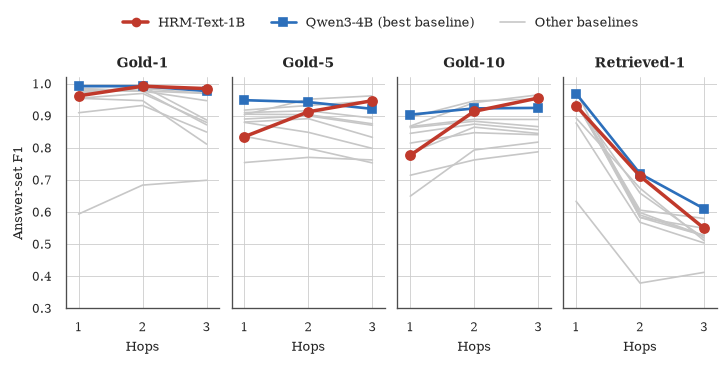

In [24]:
# Full-width `figure*`: answer-set F1 against the number of KG hops the question needs,
# one panel per context variant. This is where HRM-Text and the LLM baselines diverge.
def plot_metaqa_hops(fname="kgqa_metaqa_hops"):
    x = np.arange(len(HOPS))
    fig, axes = plt.subplots(1, len(VARIANT_ORDER), figsize=(PAGE_W, 2.5),
                             sharey=True, gridspec_kw={"wspace": 0.08})

    for ax, variant in zip(axes, VARIANT_ORDER):
        mat = (
            metaqa[metaqa["variant"] == variant]
            .set_index("arch")[[f"val/set_f1_{h}" for h in HOPS]]
            .reindex(METAQA_ORDER)
        )
        for arch in mat.index.drop([HRM_ARCH, METAQA_BEST]):
            ax.plot(x, mat.loc[arch], color="0.78", linewidth=1.0, zorder=1)
        ax.plot(x, mat.loc[METAQA_BEST], color=TRM_COLOR, marker="s", markersize=4.5,
                linewidth=1.6, zorder=3)
        ax.plot(x, mat.loc[HRM_ARCH], color=ACCENT, marker="o", markersize=5.5,
                linewidth=2.1, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels([h.replace("hop", "") for h in HOPS], fontsize=8)
        ax.set_xlim(-0.2, len(HOPS) - 0.8)
        ax.set_title(variant, fontsize=8.5)
        ax.set_xlabel("Hops", fontsize=8)
        ax.tick_params(labelsize=7)

    axes[0].set_ylim(0.3, 1.02)
    axes[0].set_ylabel("Answer-set F1", fontsize=8)

    handles = [
        mpl.lines.Line2D([], [], color=ACCENT, marker="o", linewidth=2.1, label=HRM_ARCH),
        mpl.lines.Line2D([], [], color=TRM_COLOR, marker="s", linewidth=1.6,
                         label=f"{METAQA_BEST} (best baseline)"),
        mpl.lines.Line2D([], [], color="0.78", linewidth=1.0, label="Other baselines"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12),
               ncol=3, fontsize=7.5, frameon=False)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_metaqa_hops()


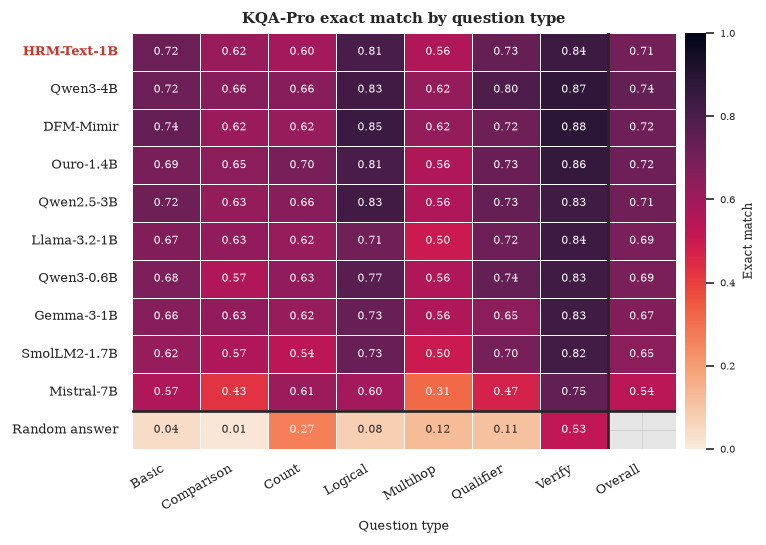

In [25]:
# KQA-Pro by question type. The random-answer row is appended below the separator: Verify
# is binary and Count has a small label set, so a high score there is not evidence of much.
def plot_kqapro_types(fname="kgqa_kqapro_types"):
    grid = kqa_by_type.copy()
    grid["Overall"] = kqapro["val/exact_match"].reindex(KQA_ORDER)
    grid.loc[RANDOM_LABEL] = kqa_random.reindex(grid.columns)  # Overall -> NaN

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.3 * len(grid) + 1.2))
    sns.heatmap(
        grid, mask=grid.isna(), annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 6.5},
        cbar_kws={"label": "Exact match", "pad": 0.015}, ax=ax,
    )
    ax.set_facecolor("0.90")
    ax.axhline(len(KQA_ORDER), color="0.15", linewidth=1.6)
    ax.axvline(len(KQA_TYPES), color="0.15", linewidth=1.6)

    ax.set_xticklabels(grid.columns, rotation=30, ha="right", fontsize=7.5)
    ax.set_yticklabels(grid.index, rotation=0, fontsize=7.5)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    ax.set_ylabel("")
    ax.set_xlabel("Question type", fontsize=8)
    ax.set_title("KQA-Pro exact match by question type", fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


plot_kqapro_types()


In [26]:
# Shared LaTeX emitter for the RQ3 tables: HRM-Text rows come first with the label in bold,
# and a trailing random-answer row (if present) is set off by its own rule. A MultiIndex
# index (the summary's (model, Clip)) is printed as plain columns, one label per row.
def family_column(lines, families):
    """Prepend a column naming each row's family, rotated 90 degrees and spanning the family's rows
    (needs the multirow and graphicx packages). `families`: one name per body row, None for a
    control row. Families are separated by a rule."""
    top, head = lines.index(r"\toprule"), lines.index(r"\midrule")
    out = lines[:top + 1] + [" & " + ln for ln in lines[top + 1:head]] + [lines[head]]
    rows = lines[head + 1:head + 1 + len(families)]
    for i, (fam, row) in enumerate(zip(families, rows)):
        if fam is None or (i and families[i - 1] == fam):
            out.append(" & " + row)
            continue
        n = next((j for j in range(i, len(families)) if families[j] != fam), len(families)) - i
        if i:
            out.append(r"\midrule")
        name = rf"\rotatebox[origin=c]{{90}}{{\footnotesize {fam}}}"
        # A one-row family takes the rotated name in the cell itself, so the row grows to fit it.
        out.append((name if n == 1 else rf"\multirow{{{n}}}{{*}}{{{name}}}") + " & " + row)
    return out + lines[head + 1 + len(families):]


def kgqa_table_latex(tbl, caption, label, column_format, wide=False, rule_before=None, families=None):
    """`families` (optional): see `family_column`; `column_format` must then include its column."""
    tbl = bold_best(tbl, "{:.3f}".format, 3, skip_rows=[RANDOM_LABEL])
    multi = isinstance(tbl.index, pd.MultiIndex)
    lines = (tbl.reset_index() if multi else tbl.rename_axis(None)).to_latex(
        column_format=column_format, index=not multi,
        escape=False, multicolumn=True, multicolumn_format="c",
    ).splitlines()
    lines = [rf"\textbf{{{HRM_ARCH}}}" + ln[len(HRM_ARCH):] if ln.startswith(HRM_ARCH) else ln
             for ln in lines]
    if families is not None:
        lines = family_column(lines, families)
    if rule_before is not None:
        at = next(i for i, ln in enumerate(lines) if ln.lstrip(" &").startswith(rule_before))
        lines.insert(at, r"\midrule")

    env = "table*" if wide else "table"
    body = [r"\resizebox{\textwidth}{!}{%", *lines, r"}"] if wide else lines
    return "\n".join([
        rf"\begin{{{env}}}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        *body,
        rf"\end{{{env}}}",
    ])


metaqa_table = pd.concat(
    {v: pd.DataFrame({"F1": metaqa_f1[v], "EM": metaqa_em[v]}) for v in VARIANT_ORDER},
    axis=1,
).reindex(columns=pd.MultiIndex.from_product([VARIANT_ORDER, ["F1", "EM"]]))
metaqa_table.loc[RANDOM_LABEL] = [
    metaqa_random[v] for v in VARIANT_ORDER for _ in ("F1", "EM")
]

print(kgqa_table_latex(
    metaqa_table,
    "MetaQA answer-set F1 and exact match (EM) under four knowledge-graph contexts. "
    "\\textbf{Gold-$k$}: gold subgraph, questions with exactly $k$ gold answers. "
    "\\textbf{Retrieved-1}: single-answer questions whose context comes from a retriever "
    "instead of the gold subgraph. The random-answer control is per-variant, hence "
    "identical in both sub-columns. Best model per column in bold.",
    "tab:kgqa_metaqa",
    column_format="l|" + "cc|" * (len(VARIANT_ORDER) - 1) + "cc",
    wide=True,
    rule_before=RANDOM_LABEL,
))

metaqa_table.round(3)


\begin{table*}[t]
\centering
\small
\caption{MetaQA answer-set F1 and exact match (EM) under four knowledge-graph contexts. \textbf{Gold-$k$}: gold subgraph, questions with exactly $k$ gold answers. \textbf{Retrieved-1}: single-answer questions whose context comes from a retriever instead of the gold subgraph. The random-answer control is per-variant, hence identical in both sub-columns. Best model per column in bold.}
\label{tab:kgqa_metaqa}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{Gold-1} & \multicolumn{2}{c}{Gold-5} & \multicolumn{2}{c}{Gold-10} & \multicolumn{2}{c}{Retrieved-1} \\
 & F1 & EM & F1 & EM & F1 & EM & F1 & EM \\
\midrule
\textbf{HRM-Text-1B} & 0.980 & 0.980 & 0.898 & 0.637 & 0.916 & 0.566 & 0.731 & 0.728 \\
Qwen3-4B & \textbf{0.987} & \textbf{0.987} & 0.938 & 0.759 & 0.922 & 0.533 & \textbf{0.766} & \textbf{0.764} \\
DFM-Mimir & 0.977 & 0.975 & \textbf{0.939} & \textbf{0.769} & \textbf{0.943} & \textbf{0.632} & 0.693 & 0.

Gold-1        Gold-5        Gold-10        Retrieved-1       
                  F1     EM     F1     EM      F1     EM          F1     EM
arch                                                                       
HRM-Text-1B    0.980  0.980  0.898  0.637   0.916  0.566       0.731  0.728
Qwen3-4B       0.987  0.987  0.938  0.759   0.922  0.533       0.766  0.764
DFM-Mimir      0.977  0.975  0.939  0.769   0.943  0.632       0.693  0.693
Ouro-1.4B      0.970  0.970  0.932  0.749   0.943  0.613       0.706  0.706
Qwen2.5-3B     0.977  0.977  0.906  0.657   0.886  0.384       0.695  0.690
Qwen2.5-1.5B   0.950  0.950  0.895  0.607   0.863  0.301       0.711  0.711
Llama-3.2-1B   0.935  0.932  0.868  0.536   0.873  0.331       0.688  0.685
Qwen3-0.6B     0.942  0.942  0.887  0.586   0.841  0.275       0.688  0.685
Gemma-3-1B     0.897  0.895  0.842  0.479   0.847  0.285       0.650  0.645
SmolLM2-1.7B   0.905  0.902  0.796  0.353   0.768  0.132       0.693  0.693
Mistral-7B     0.659  0.659  0.763  0.316   0.787  0.195       0.475  0.475
Random answer  0.083  0.083  0.020  0.020   0.019  0.019       0.053  0.053

In [27]:
kqa_table = kqa_by_type.copy()
kqa_table.insert(0, "Overall", kqapro["val/exact_match"].reindex(KQA_ORDER))
kqa_table.loc[RANDOM_LABEL] = kqa_random.reindex(kqa_table.columns)

print(kgqa_table_latex(
    kqa_table,
    "KQA-Pro exact match, overall and per question type. The random-answer control is "
    "high on Verify (binary) and Count (small label set), so those columns should be read "
    "against it rather than against 0. Best model per column in bold.",
    "tab:kgqa_kqapro",
    column_format="l|c|" + "c" * len(KQA_TYPES),
    wide=True,
    rule_before=RANDOM_LABEL,
))

kqa_table.round(3)


\begin{table*}[t]
\centering
\small
\caption{KQA-Pro exact match, overall and per question type. The random-answer control is high on Verify (binary) and Count (small label set), so those columns should be read against it rather than against 0. Best model per column in bold.}
\label{tab:kgqa_kqapro}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|ccccccc}
\toprule
 & Overall & Basic & Comparison & Count & Logical & Multihop & Qualifier & Verify \\
\midrule
\textbf{HRM-Text-1B} & 0.707 & 0.725 & 0.616 & 0.598 & 0.808 & 0.562 & 0.735 & 0.842 \\
Qwen3-4B & \textbf{0.742} & 0.725 & \textbf{0.659} & 0.659 & 0.827 & \textbf{0.625} & \textbf{0.796} & 0.874 \\
DFM-Mimir & 0.718 & \textbf{0.735} & 0.616 & 0.622 & \textbf{0.846} & \textbf{0.625} & 0.722 & \textbf{0.884} \\
Ouro-1.4B & 0.717 & 0.693 & 0.646 & \textbf{0.695} & 0.808 & 0.562 & 0.728 & 0.863 \\
Qwen2.5-3B & 0.714 & 0.720 & 0.628 & 0.659 & 0.827 & 0.562 & 0.735 & 0.832 \\
Llama-3.2-1B & 0.688 & 0.672 & 0.634 & 0.622 & 0.712 & 0.500 &

,Overall,Basic,Comparison,Count,Logical,Multihop,Qualifier,Verify
arch,,,,,,,,
HRM-Text-1B,0.707,0.725,0.616,0.598,0.808,0.562,0.735,0.842
Qwen3-4B,0.742,0.725,0.659,0.659,0.827,0.625,0.796,0.874
DFM-Mimir,0.718,0.735,0.616,0.622,0.846,0.625,0.722,0.884
Ouro-1.4B,0.717,0.693,0.646,0.695,0.808,0.562,0.728,0.863
Qwen2.5-3B,0.714,0.720,0.628,0.659,0.827,0.562,0.735,0.832
Llama-3.2-1B,0.688,0.672,0.634,0.622,0.712,0.500,0.716,0.842
Qwen3-0.6B,0.687,0.683,0.567,0.634,0.769,0.562,0.741,0.832
Gemma-3-1B,0.672,0.661,0.634,0.622,0.731,0.562,0.648,0.832
SmolLM2-1.7B,0.647,0.624,0.567,0.537,0.731,0.500,0.698,0.821


In [28]:
# Single-column RQ3 headline table: exact match per benchmark, one row per (model, clipping),
# no per-hop / per-question-type breakdown (the two tables above go to the appendix). MetaQA
# is averaged over its four context variants (`--` unless all four exist); KQA-Pro has no
# Qwen2.5-1.5B run. Rows grouped by architecture family (HRM, looped, standard transformer), named
# in a rotated left column; within a family HRM-Text-1B first, then by best MetaQA EM, a model's
# clipped row before its unclipped one.
CLIP_MARK = {True: r"$\checkmark$", False: r"$\times$"}
rq3_summary = pd.DataFrame({
    ("MetaQA", "EM"): metaqa_all.pivot(index=["arch", "clipped"], columns="variant",
                                       values="val/exact_match")[VARIANT_ORDER].mean(axis=1, skipna=False),
    ("KQA-Pro", "EM"): kqapro_all.set_index(["arch", "clipped"])["val/exact_match"],
})
best_em = rq3_summary[("MetaQA", "EM")].groupby(level="arch").max()
rq3_order = group_by_family(
    [HRM_ARCH] + list(best_em.drop(index=HRM_ARCH).sort_values(ascending=False).index))
rq3_summary = rq3_summary.reindex(
    [(a, c) for a in rq3_order for c in (True, False) if (a, c) in rq3_summary.index]
)
rq3_summary.index = pd.MultiIndex.from_tuples(
    [(a, CLIP_MARK[c]) for a, c in rq3_summary.index], names=["", "Clip"]
)
rq3_families = [FAMILY_SHORT[arch_family(a)] for a, _ in rq3_summary.index]
rq3_summary.loc[(RANDOM_LABEL, ""), :] = [metaqa_random.mean(), np.nan]

print(kgqa_table_latex(
    rq3_summary,
    "Knowledge-graph QA summary, exact match (EM). \\textbf{MetaQA}: averaged over the four "
    "context variants (Gold-1/5/10, Retrieved-1). \\textbf{KQA-Pro}: overall. "
    "\\textbf{Clip}: fine-tuned with gradient-norm clipping at 1.0 ($\\checkmark$) or without "
    "($\\times$); HRM-Text-1B and DFM-Mimir are reported both ways. Per-variant, per-hop and "
    "per-question-type results (clipped run where both exist) are in the appendix. "
    "Rows are grouped by architecture: HRM (hierarchical recurrent model), looped transformer, "
    "and standard transformer. Best model per column in bold.",
    "tab:kgqa_summary",
    column_format="clc|c|c",
    rule_before=RANDOM_LABEL,
    families=rq3_families + [None],
))

rq3_summary.round(3)


\begin{table}[t]
\centering
\small
\caption{Knowledge-graph QA summary, exact match (EM). \textbf{MetaQA}: averaged over the four context variants (Gold-1/5/10, Retrieved-1). \textbf{KQA-Pro}: overall. \textbf{Clip}: fine-tuned with gradient-norm clipping at 1.0 ($\checkmark$) or without ($\times$); HRM-Text-1B and DFM-Mimir are reported both ways. Per-variant, per-hop and per-question-type results (clipped run where both exist) are in the appendix. Rows are grouped by architecture: HRM (hierarchical recurrent model), looped transformer, and standard transformer. Best model per column in bold.}
\label{tab:kgqa_summary}
\begin{tabular}{clc|c|c}
\toprule
 &  & Clip & MetaQA & KQA-Pro \\
 &  &  & EM & EM \\
\midrule
\multirow{4}{*}{\rotatebox[origin=c]{90}{\footnotesize HRM}} & \textbf{HRM-Text-1B} & $\checkmark$ & 0.728 & 0.707 \\
 & \textbf{HRM-Text-1B} & $\times$ & 0.691 & 0.697 \\
 & DFM-Mimir & $\checkmark$ & \textbf{0.767} & 0.718 \\
 & DFM-Mimir & $\times$ & 0.760 & 0.693 \\
\midru

/tmp/ipykernel_513612/3090060534.py:54: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  rounded = tbl.drop(index=list(skip_rows), errors="ignore").round(decimals)


MetaQA KQA-Pro
                               EM      EM
              Clip                       
HRM-Text-1B   $\checkmark$  0.728   0.707
              $\times$      0.691   0.697
DFM-Mimir     $\checkmark$  0.767   0.718
              $\times$      0.760   0.693
Ouro-1.4B     $\checkmark$  0.759   0.717
Qwen3-4B      $\checkmark$  0.761   0.742
Qwen2.5-3B    $\checkmark$  0.677   0.714
Qwen2.5-1.5B  $\times$      0.642     NaN
Qwen3-0.6B    $\times$      0.622   0.687
Llama-3.2-1B  $\times$      0.621   0.688
Gemma-3-1B    $\times$      0.576   0.672
SmolLM2-1.7B  $\times$      0.520   0.647
Mistral-7B    $\checkmark$  0.411   0.539
Random answer               0.044     NaN

## RQ2.1'' — Full backprop over the $(H, L)$ grid

RQ2.1' re-ran a single column ($L = 6$) with full backprop. This section extends the comparison
to a sparse subset of the RQ2.1 grid: 11 cells with $H \in \{1, 2, 3\}$ and
$L \in \{1, 3, 6, 12, 24\}$, plus 6 cells in the $H \geq 4$ region where the RQ2.1 grid collapses
($H4L1$, $H4L3$, $H4L6$, $H5L6$, $H6L2$, $H6L6$; `scripts/run_graphqa_fullbp_local.sh`). Two questions:

- the flat $H = 1$ row: under the truncated budget only the last 4 low-level steps receive gradient
  at $H = 1$ (4 of 6 at $L = 6$, 4 of 24 at $L = 24$). Does full backprop make $L$ matter?
- the $H \geq 4$ collapse: at $H \geq 4$ the truncated budget is $H_{bp} = 4$, $L_{bp} = 1$, so almost no
  low-level step gets gradient. Does full backprop rescue those rows?

Every $H \leq 3$ cell is retrained from scratch in **both** regimes with the original recipe
(`cfg_graphqa`, 4,358 steps, seed 0), so the truncated panel is a same-hardware rerun, not the
RQ2.1 grid itself (whose values are kept in the table as a reference). The $H = 1$ cells at
$L \in \{1, 6, 24\}$ have a second seed and show the seed mean. Test split, $n = 385$: one
binomial standard error is about 2.5 points per cell. In the $H \geq 4$ region only $H4L6$ and
$H6L6$ are rerun with truncated BPTT (to check that the collapse reproduces locally). Grey cells
were not run.

$H1L1$, $H1L3$ and $H2L1$ have the same gradient graph in both regimes (after the backprop
warm-up) and serve as controls for the full-backprop path.

In [29]:
# Local full-BP vs truncated reruns (scripts/run_graphqa_fullbp_local.sh): one row per run, exported
# from the eval reports by scripts/summarize_graphqa_fullbp.py. Repeated seeds are averaged.
fullbp_local = pd.read_csv(RESULTS_DIR / "graphqa-fullbp-local.csv")


# Reindexed on the full RQ2.1 axes, so every cell sits where it does in `ablation_hl_grid`.
def local_grid(regime):
    return (
        fullbp_local[fullbp_local["bp"] == regime]
        .pivot_table(index="H", columns="L", values="accuracy", aggfunc="mean")
        .reindex(index=H_VALS, columns=L_VALS)
    )


local_grids = {regime: local_grid(regime) for regime in (TRUNC_BP, FULL_BP)}

# Per-cell comparison; the matching RQ2.1 grid cell checks that the truncated rerun reproduces it.
fullbp_local_table = fullbp_local.pivot_table(
    index=["H", "L"], columns="bp", values="accuracy", aggfunc="mean"
)[[TRUNC_BP, FULL_BP]]
fullbp_local_table["delta"] = fullbp_local_table[FULL_BP] - fullbp_local_table[TRUNC_BP]
fullbp_local_table["seeds"] = fullbp_local.groupby(["H", "L"])["seed"].nunique()
fullbp_local_table["truncated (RQ2.1 grid)"] = (
    abl_grid[abl_grid["family"] == "HRM"].set_index(["H", "L"])["accuracy"]
)
fullbp_local_table.round(3)

bp    Truncated BPTT (5 blocks)  Full backprop  delta  seeds  \
H L                                                            
1 1                       0.519          0.519  0.000      2   
  3                       0.517          0.514 -0.003      1   
  6                       0.506          0.512  0.005      2   
  12                      0.519          0.496 -0.023      1   
  24                      0.499          0.499  0.000      2   
2 1                       0.488          0.494  0.005      1   
  3                       0.486          0.494  0.008      1   
  6                       0.460          0.512  0.052      1   
  12                      0.455          0.525  0.070      1   
3 3                       0.439          0.496  0.057      1   
  6                       0.434          0.436  0.003      1   
  12                      0.390          0.439  0.049      1   
4 1                         NaN          0.377    NaN      1   
  3                         NaN          0.382    NaN      1   
  6                       0.000          0.003  0.003      1   
5 6                         NaN          0.000    NaN      1   
6 2                         NaN          0.000    NaN      1   
  6                       0.000          0.000  0.000      1   

bp    truncated (RQ2.1 grid)  
H L                           
1 1                    0.514  
  3                    0.504  
  6                    0.535  
  12                   0.514  
  24                   0.519  
2 1                    0.449  
  3                    0.444  
  6                    0.439  
  12                   0.405  
3 3                    0.439  
  6                    0.400  
  12                   0.447  
4 1                    0.374  
  3                    0.062  
  6                    0.055  
5 6                    0.000  
6 2                    0.000  
  6                    0.000

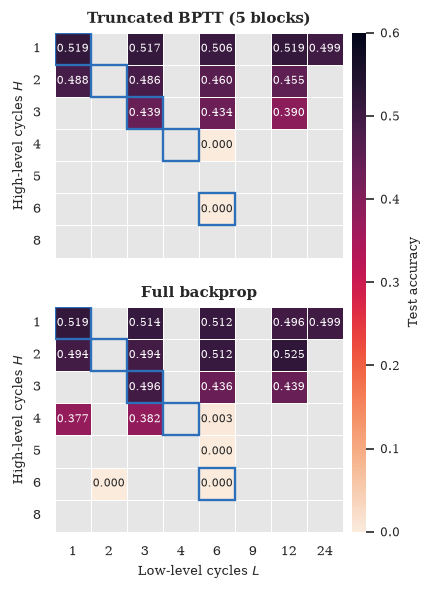

In [30]:
# Single-column figure: the RQ2.1 heatmap restricted to the locally rerun cells, truncated BPTT
# above full backprop. Same size, cell geometry, colormap and color scale as `ablation_hl_grid`,
# so the two figures can be read against each other cell for cell.
def plot_hl_heatmaps_fullbp(fname="ablation_hl_grid_fullbp"):
    vmax = np.ceil(abl_grid["accuracy"].max() * 10) / 10
    fig = plt.figure(figsize=(COL_W, 5.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.05], hspace=0.22, wspace=0.06)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    cbar_ax = fig.add_subplot(gs[:, 1])

    for ax, regime in zip(axes, [TRUNC_BP, FULL_BP]):
        grid = local_grids[regime]
        last = regime == FULL_BP
        sns.heatmap(
            grid, ax=ax, mask=grid.isna(), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=vmax, linewidths=0.4, linecolor="white",
            annot_kws={"fontsize": 6.5}, cbar=last, cbar_ax=cbar_ax if last else None,
            cbar_kws={"label": "Test accuracy"} if last else None,
        )
        ax.set_facecolor("0.90")  # cells with no run
        ax.grid(False)

        # Outline the L/H = 1 diagonal, as in the full grid.
        for i, h in enumerate(H_VALS):
            if h in L_VALS:
                ax.add_patch(mpl.patches.Rectangle(
                    (L_VALS.index(h), i), 1, 1, fill=False,
                    edgecolor=TRM_COLOR, linewidth=1.4, zorder=4,
                ))

        ax.set_title(regime, fontsize=9)
        ax.set_xticklabels(L_VALS if last else [], rotation=0, fontsize=7.5)
        ax.set_xlabel("Low-level cycles $L$" if last else "", fontsize=8)
        ax.set_yticklabels(H_VALS, rotation=0, fontsize=7.5)
        ax.set_ylabel("High-level cycles $H$", fontsize=8)
        if not last:
            ax.tick_params(axis="x", length=0)

    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_hl_heatmaps_fullbp()

**Reading.**

- *Controls.* The three cells with identical gradient graphs agree to within one point
  ($H1L1$ 0.519 / 0.519, $H1L3$ 0.517 / 0.514, $H2L1$ 0.488 / 0.494), so the full-backprop path
  itself does not shift accuracy.
- *$H = 1$: no.* Full backprop does not make $L$ matter. The row stays flat at 0.50–0.52 in both
  regimes, from $L = 1$ to $L = 24$.
- *$H \geq 2$.* Full backprop scores higher in 4 of the 5 cells (+4.9 to +7.0 points at $H2L6$,
  $H2L12$, $H3L3$, $H3L12$; +0.3 at $H3L6$). At $H = 2$ this brings accuracy back to the
  $H = 1$ level. At $H = 3$, $L \geq 6$ it does not.
- *$H \geq 4$: no.* Full backprop does not rescue the collapse: $H4L6$ 0.003, $H5L6$, $H6L2$
  and $H6L6$ 0.000. The truncated reruns reproduce it ($H4L6$ and $H6L6$ both 0.000; RQ2.1 grid 0.055
  and 0.000). The shallow cells $H4L1$ (0.377) and $H4L3$ (0.382) train, about 14 points below
  $H = 1$; $H4L1$ matches the grid (0.374). RQ2.3.2 shows this is a training divergence, not a
  depth limit.
- *Caveat.* The $H \geq 2$ cells use a single seed, and the two seeds of the truncated $H1L6$
  cell already differ by 4.7 points (0.483 vs 0.530). A single +5-point delta is therefore within
  seed noise; only the consistent sign across cells counts as evidence. The truncated reruns also
  differ from the RQ2.1 grid by up to 5 points per cell ($H2L12$: 0.455 here vs 0.405 in the grid).

## RQ2.3 — Why doesn't recursion help? (hypothesis tests)

RQ2.1–RQ2.1'' show that neither more low-level steps nor full backprop through them buys
accuracy on GraphQA, and that the grid collapses for $H \geq 4$. This section tests three
explanations with the minimal set of runs that fits one 13-hour window on two GPUs
(`scripts/run_recursion_hyp_local.sh`, W&B `HRM-RecursionHyp-Local`):

- **H1, state collapse.** With pre-norm blocks the residual stream of a recurrent module grows to
  RMS $\approx 265$ before the final norm, so the incoming state (RMS $\approx 1$) barely moves the
  output: the *gain* $\lVert f(h+\delta) - f(h)\rVert / \lVert\delta\rVert$ of a trained $L$ block
  is $\approx 0.005$ (fresh init: $\approx 0.5$). Extra $L$ steps then cannot carry information.
  Test: post-norm and peri-norm blocks, which bound the residual.
- **H3, the task.** GraphQA may split into tasks that every configuration solves and tasks that
  none does, so the average is flat whatever the recursion does. Test: per-task breakdown, and a
  pointer-chasing task whose required depth is set by the number of hops $k$.
- **TRM gap.** Our TRM differs from the paper's (no input re-injection, 1-step gradients,
  6-layer modules, pre-norm, no deep supervision). Test: a TRM matched to the paper recipe,
  minus deep supervision.

All scores pool val + test (770 GraphQA samples, one binomial SE $\approx 1.8$ points), since
two seeds of the same cell already differ by up to 4.7 points on test alone.

### RQ2.3.1 — Per-task breakdown (H3)

Accuracy per GraphQA task for every local run of RQ2.1'' (`scripts/summarize_per_group.py`),
pooled over val + test and over seeds: $\approx 140$ samples per task and cell, one binomial
SE $\approx 4$ points. Only the 30 runs with $H \leq 3$ are included: the $H \geq 4$ runs of RQ2.1''
diverged (RQ2.3.2) and would add nothing but zeros.

In [31]:
# Per-task accuracy of the local full-BP / truncated runs, one row per (run, split, task), written by
# scripts/summarize_per_group.py. Pooled over splits and seeds before any ratio is taken.
# H >= 4 runs diverged (RQ2.3.2) and are excluded.
per_task = pd.read_csv(RESULTS_DIR / "graphqa-fullbp-local-per-group.csv").query("H <= 3")
per_task["bp"] = per_task["regime"].map({"fullbp": FULL_BP, "trunc": TRUNC_BP})
task_cells = per_task.groupby(["bp", "H", "L", "group"], as_index=False)[["correct", "n"]].sum()
task_cells["accuracy"] = task_cells["correct"] / task_cells["n"]

# Per task: spread across every (regime, H, L) cell against the sampling noise of one cell.
task_spread = task_cells.groupby("group").agg(
    mean=("accuracy", "mean"), min=("accuracy", "min"), max=("accuracy", "max"), n=("n", "median"))
task_spread["range"] = task_spread["max"] - task_spread["min"]
task_spread["se"] = np.sqrt(task_spread["mean"] * (1 - task_spread["mean"]) / task_spread["n"])
task_spread["class"] = np.select(
    [task_spread["min"] >= 0.9, task_spread["max"] <= 0.3, task_spread["range"] > 4 * task_spread["se"]],
    ["ceiling", "floor", "varies"], "flat")
TASK_ORDER = task_spread.sort_values("mean", ascending=False).index.tolist()
task_spread.loc[TASK_ORDER].round(3)

,mean,min,max,n,range,se,class
group,,,,,,,
Reachability,1.000,1.000,1.000,64.0,0.000,0.000,ceiling
CycleCheck,0.969,0.893,1.000,75.0,0.107,0.020,varies
NodeCount,0.716,0.266,0.906,64.0,0.641,0.056,varies
EdgeExistence,0.714,0.645,0.790,62.0,0.145,0.057,flat
ShortestPath,0.519,0.433,0.604,67.0,0.172,0.061,flat
EdgeCount,0.453,0.109,0.582,55.0,0.473,0.067,varies
TriangleCounting,0.414,0.272,0.531,81.0,0.259,0.055,varies
NodeDegree,0.356,0.293,0.415,82.0,0.122,0.053,flat
ConnectedNodes,0.229,0.151,0.295,73.0,0.144,0.049,floor


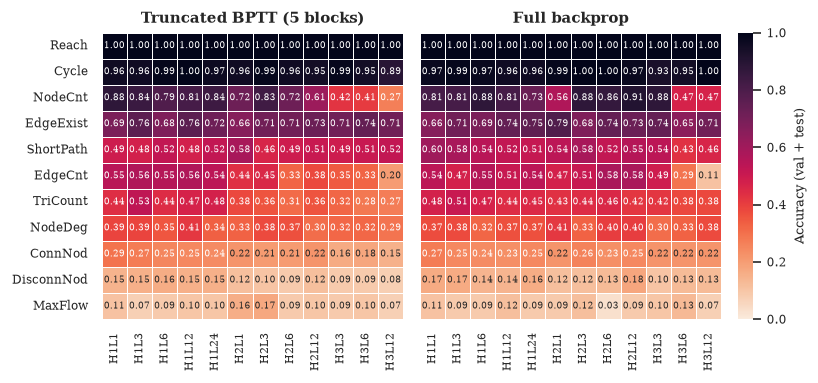

In [32]:
# Full-width figure: task x (H, L) heatmaps, truncated BPTT left, full backprop right, tasks sorted
# by mean accuracy. Same colormap as the grid figures.
def plot_task_cells(fname="recursion_hyp_per_task"):
    regimes = [TRUNC_BP, FULL_BP]
    grids = {}
    for regime in regimes:
        sub = task_cells[task_cells["bp"] == regime].sort_values(["H", "L"])
        sub = sub.assign(cell=[f"H{h}L{l}" for h, l in zip(sub["H"], sub["L"])])
        order = list(dict.fromkeys(sub["cell"]))
        grids[regime] = (sub.pivot(index="group", columns="cell", values="accuracy")
                         .reindex(index=TASK_ORDER, columns=order))
    widths = [g.shape[1] for g in grids.values()] + [0.6]
    fig = plt.figure(figsize=(PAGE_W, 3.1))
    gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.08)
    cbar_ax = fig.add_subplot(gs[0, 2])
    for j, regime in enumerate(regimes):
        ax = fig.add_subplot(gs[0, j])
        last = j == len(regimes) - 1
        sns.heatmap(grids[regime], ax=ax, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                    linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
                    cbar=last, cbar_ax=cbar_ax if last else None,
                    cbar_kws={"label": "Accuracy (val + test)"} if last else None)
        ax.set_facecolor("0.90")
        ax.grid(False)
        ax.set_title(regime, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6.5)
        ax.set_yticklabels([TASK_ABBREV.get(t, t) for t in TASK_ORDER] if j == 0 else [], fontsize=7)
        if j:
            ax.tick_params(axis="y", length=0)
    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_task_cells()

**Reading.**

- *Ceiling everywhere.* Reachability is 1.000 in every cell and CycleCheck 0.97 on average
  (0.89–1.00).
- *Floor everywhere.* MaximumFlow (0.10; the "old" split does not give edge capacities),
  DisconnectedNodes (0.13) and ConnectedNodes (0.23).
- *Flat within noise.* EdgeExistence (0.71), ShortestPath (0.52) and NodeDegree (0.36) vary by
  12–17 points across 24 cells, within $\pm 2$ SE of a cell.
- *The only tasks that move* are NodeCount, EdgeCount and TriangleCounting, and they move with $H$
  and in the wrong direction. Pooled over both regimes, NodeCount goes from 0.84 at $H1L1$ to 0.37
  at $H3L12$, EdgeCount from 0.54 to 0.15 and TriangleCounting from 0.46 to 0.33. Along the
  $H = 1$ row they stay flat in $L$ (NodeCount 0.78–0.84).

So on GraphQA the multi-hop tasks that recursion could help (ShortestPath, MaximumFlow,
ConnectedNodes) are flat or at the floor, and the tasks that react to recursion are simple
counting tasks that it degrades. The flat average is not hiding a gain on some tasks offset by a loss
on others: no task improves with $H$ or $L$.

### RQ2.3.2 — The $H \geq 4$ rows: depth or divergence?

On Jean Zay the whole $H \geq 4$ region of the grid scores $\approx 0$, in both gradient
regimes of RQ2.1'. If this were a depth limit, the training loss would plateau at a moderate
value. The curves below are the Jean Zay training losses (W&B `HRM-GraphQA-Ablation`, exported by
`scripts/pull_wandb_curves.py`), smoothed over 20 logged steps.

In [33]:
# Jean Zay training curves at fixed L = 6 (plus the other collapsed cells), one panel per gradient
# regime, one line per H. Sequential color = recursion depth H.
curves = pd.read_csv(RESULTS_DIR / "recursion-hyp-h4-curves.csv")
parts = curves["run"].str.extract(r"graphqa_H(?P<H>\d+)_L(?P<L>\d+)(?P<fullbp>_fullbp)?$")
curves = curves.assign(H=parts["H"].astype(int), L=parts["L"].astype(int),
                       bp=np.where(parts["fullbp"].notna(), FULL_BP, TRUNC_BP))
curves = curves.sort_values(["run", "step"])
curves["loss_smooth"] = curves.groupby("run")["train/loss"].transform(lambda s: s.rolling(20, min_periods=1).mean())

# Where each run ends vs its best point: a late loss far above the minimum is a divergence.
h4_summary = curves.groupby(["bp", "H", "L"]).agg(
    min_loss=("train/loss", "min"),
    step_of_min=("step", lambda s: int(s.loc[curves.loc[s.index, "train/loss"].idxmin()])),
    final_loss=("loss_smooth", "last"))
h4_summary = h4_summary.join(
    abl_grid[abl_grid["family"] == "HRM"].set_index(["H", "L"])["accuracy"].rename("JZ acc (truncated)"),
    on=["H", "L"])
h4_summary.round(3)

min_loss  step_of_min  final_loss  \
bp                        H L                                       
Full backprop             2 6      0.018         4490       0.116   
                          3 6      0.053         4490       0.222   
                          4 6      0.348          235       0.768   
                          6 6      0.671          195       2.584   
Truncated BPTT (5 blocks) 1 6      0.006         4490       0.053   
                          2 6      0.067         4490       0.237   
                          3 6      0.121         4490       0.381   
                          4 1      0.091         4490       0.410   
                            3      0.367         4430       0.697   
                            6      0.825         4210       2.040   
                          5 6      1.423           90       2.622   
                          6 2      1.278          135       2.622   
                            6      1.834           55       2.622   
                          8 12     2.276         1675       2.622   

                                JZ acc (truncated)  
bp                        H L                       
Full backprop             2 6                0.439  
                          3 6                0.400  
                          4 6                0.055  
                          6 6                0.000  
Truncated BPTT (5 blocks) 1 6                0.535  
                          2 6                0.439  
                          3 6                0.400  
                          4 1                0.374  
                            3                0.062  
                            6                0.055  
                          5 6                0.000  
                          6 2                0.000  
                            6                0.000  
                          8 12               0.000

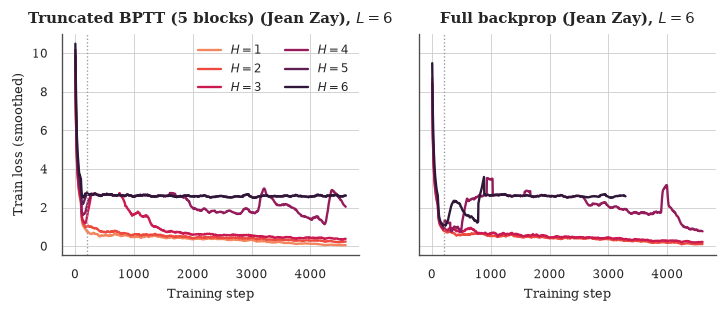

In [34]:
def plot_h4_curves(fname="recursion_hyp_h4_loss", L=6):
    sub = curves[curves["L"] == L]
    H_list = sorted(sub["H"].unique())
    colors = dict(zip(H_list, sns.color_palette("rocket_r", len(H_list) + 1)[1:]))
    fig, axes = plt.subplots(1, 2, figsize=(COL_W * 2.1, 2.4), sharey=True)
    for ax, regime in zip(axes, [TRUNC_BP, FULL_BP]):
        for H in H_list:
            run = sub[(sub["H"] == H) & (sub["bp"] == regime)]
            if run.empty:
                continue
            ax.plot(run["step"], run["loss_smooth"], color=colors[H], linewidth=1.4, label=f"$H = {H}$")
        ax.set_title(f"{regime} (Jean Zay), $L = {L}$", fontsize=9)
        ax.set_xlabel("Training step", fontsize=8)
        ax.axvline(200, color="0.6", linewidth=0.8, linestyle=":")  # end of LR warmup
        ax.tick_params(labelsize=7)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Train loss (smoothed)", fontsize=8)
    axes[0].legend(fontsize=7, ncol=2)
    save_fig(fig, fname)
    plt.show()


plot_h4_curves()

In [35]:
# The same question on the local reruns of the H >= 4 cells (scripts/run_graphqa_fullbp_local.sh:
# full backprop *without* grad checkpointing, plus truncated reruns of H4L6 / H6L6), exported from W&B
# `HRM-GraphQA-FullBP-Local`. H1L6 / H3L6 full backprop are references that train normally. Logged
# every 5 steps, so the 20-point smoothing spans 100 steps. LR warmup ends at step 200.
curves_local = pd.read_csv(RESULTS_DIR / "recursion-hyp-h4-curves-local.csv")
parts = curves_local["run"].str.extract(r"graphqa_H(?P<H>\d+)_L(?P<L>\d+)_(?P<regime>fullbp|trunc)_local_s\d+$")
curves_local = curves_local.assign(
    H=parts["H"].astype(int), L=parts["L"].astype(int),
    bp=parts["regime"].map({"fullbp": FULL_BP, "trunc": TRUNC_BP}),
).sort_values(["run", "step"])
curves_local["loss_smooth"] = curves_local.groupby("run")["train/loss"].transform(
    lambda s: s.rolling(20, min_periods=1).mean())

by_cell = ["bp", "H", "L"]
h4_local_summary = curves_local.groupby(by_cell).agg(
    min_loss=("loss_smooth", "min"), final_loss=("loss_smooth", "last"))
# Height of the post-warmup spike, and the first step after which the loss is back below 1.
after = curves_local[curves_local["step"] > 200]
h4_local_summary["peak_after_warmup"] = after.groupby(by_cell)["loss_smooth"].max()
h4_local_summary["recovered_at"] = after.groupby(by_cell).apply(
    lambda g: g.loc[g["loss_smooth"].idxmax():].query("loss_smooth < 1")["step"].min())
h4_local_summary = h4_local_summary.join(
    fullbp_local.groupby(by_cell)["accuracy"].mean().rename("local acc (test)"))
h4_local_summary.round(3)

min_loss  final_loss  peak_after_warmup  \
bp                        H L                                            
Full backprop             1 6     0.061       0.069              0.778   
                          3 6     0.138       0.191              1.719   
                          4 1     0.375       0.424              1.757   
                            3     0.337       0.383              2.675   
                            6     0.824       2.639              2.729   
                          5 6     0.950       2.838              2.879   
                          6 2     0.933       2.621              2.763   
                            6     1.096       2.621              3.288   
Truncated BPTT (5 blocks) 4 6     0.695       0.704              3.486   
                          6 6     2.153       2.622              2.718   

                               recovered_at  local acc (test)  
bp                        H L                                  
Full backprop             1 6         220.0             0.512  
                          3 6         765.0             0.436  
                          4 1         985.0             0.377  
                            3        1155.0             0.382  
                            6           NaN             0.003  
                          5 6           NaN             0.000  
                          6 2           NaN             0.000  
                            6           NaN             0.000  
Truncated BPTT (5 blocks) 4 6        4210.0             0.000  
                          6 6           NaN             0.000

**Reading.**

- *Divergence after the LR warmup.* On Jean Zay, $H5L6$, $H6L2$ and $H6L6$ reach their lowest loss
  (1.3–1.8) within the first 135 steps, still inside the LR warmup, then settle on a flat plateau at
  2.62. That value is the same in every collapsed run, i.e. the constant-output level. The local
  reruns show the mechanism in more detail. Every run with $H \geq 3$ spikes once the peak LR
  ($3 \times 10^{-4}$) is reached, and the peak grows with the unrolled depth:
  - $H1L6$ does not spike (0.78);
  - $H3L6$ peaks at 1.72 and $H4L1$ at 1.76;
  - $H4L3$ peaks at 2.68;
  - $H4L6$, $H5L6$, $H6L2$ and $H6L6$ peak at 2.7–3.3.
- *Recovery decides the score.* $H3L6$, $H4L1$ and $H4L3$ get back below loss 1 by steps
  765–1155 and end at 0.19–0.42 (test accuracy 0.38–0.44). The other full-backprop runs stay on the
  plateau until the end (final loss 2.6–2.8, accuracy 0.000–0.003). The truncated $H4L6$ rerun only
  leaves the plateau around step 3,500, ending at loss 0.70. It still scores 0.000, most likely
  because evaluation uses EMA weights (decay 0.999, a $\approx$1,000-step horizon) that mostly
  average the plateau.
- *Not the gradient regime.* The collapse happens with truncated BPTT, with full backprop plus
  grad checkpointing (Jean Zay), and with full backprop without checkpointing (local). Whether a
  given cell recovers is partly luck: $H4L3$ recovers locally (0.382) but not in the RQ2.1 grid
  (0.062).

The $H \geq 4$ zeros are therefore a training instability, not evidence that deep recursion
cannot solve GraphQA. Nothing here tests a fix; a lower peak LR or a longer warmup are the obvious
candidates. The $H \geq 4$ cells should be read as "diverged", not as accuracy 0.

### RQ2.3.3 — State collapse: gain probe and $L = 1$ at inference (H1)

Two measurements per trained model:

- the **gain** of each recursion step, $\lVert f(h+\delta+x) - f(h+x)\rVert / \lVert\delta\rVert$ with
  $\delta = \varepsilon\,\mathrm{rms}(h)\,\mathcal N(0, I)$, $\varepsilon = 1$, measured in fp32 on 12 packed val
  samples (`scripts/probe_gain_ckpt.py`; bf16 rounding hides gains below $\approx 0.04$). The residual
  RMS before the final norm is logged alongside: it is what drowns the incoming state in a pre-norm
  block. `fresh` is the same architecture at initialisation.
- the **$L = 1$ override**: the trained $L = 6$ model is evaluated with `--L_cycles 1`. If accuracy does
  not drop, the model does not use its extra $L$ steps.

Arms (full backprop, 12-layer model = 6 layers per module unless noted): `pre` is the RQ2.1''
reference, `peri` adds a norm on every sublayer output (Peri-LN), which bounds the residual growth,
`post` is the original HRM / TRM post-norm.

In [36]:
# Run name -> (arm, H, L) for both run families: graphqa_H<H>_L<L>_{fullbp,trunc}_local_s<seed>
# (pre-norm reference) and graphqa_<arm>_H<H>_L<L>_s<seed> (scripts/run_recursion_hyp_local.sh).
ARM_ORDER = ["pre", "pre (truncated)", "peri", "post", "peri-2l", "trm-matched"]
ARM_LABELS = {"pre": "pre-norm", "pre (truncated)": "pre-norm, truncated", "peri": "peri-norm",
              "post": "post-norm", "peri-2l": "peri-norm, 2-layer modules", "trm-matched": "TRM (paper recipe)"}


def split_run(runs):
    pre = runs.str.extract(r"graphqa_H(?P<H>\d+)_L(?P<L>\d+)_(?P<regime>fullbp|trunc)_local_s\d+$")
    new = runs.str.extract(r"graphqa_(?P<arm>[a-z0-9-]+)_H(?P<H>\d+)_L(?P<L>\d+)_s\d+$")
    return pd.DataFrame({
        "arm": new["arm"].fillna(pre["regime"].map({"fullbp": "pre", "trunc": "pre (truncated)"})),
        "H": new["H"].fillna(pre["H"]).astype(int),
        "L": new["L"].fillna(pre["L"]).astype(int),
    }, index=runs.index)


# Gain / pre-norm RMS, averaged over the recursion steps of each role (H or L).
probe_raw = pd.read_csv(RESULTS_DIR / "recursion-hyp-probe.csv")
probe_raw = probe_raw[(probe_raw["dtype"] == "fp32") & (probe_raw["eps"] == 1.0) & (probe_raw["L_override"] == 0)]
probe_raw = probe_raw.join(split_run(probe_raw["run"]))
probe_mean = probe_raw.groupby(["arm", "H", "L", "init", "stat", "role"])["value"].mean()
gain_tbl = pd.DataFrame({
    "gain L": probe_mean.xs(("trained", "gain", "L"), level=["init", "stat", "role"]),
    "gain H": probe_mean.xs(("trained", "gain", "H"), level=["init", "stat", "role"]),
    "pre-norm RMS L": probe_mean.xs(("trained", "prenorm_rms", "L"), level=["init", "stat", "role"]),
    "pre-norm RMS H": probe_mean.xs(("trained", "prenorm_rms", "H"), level=["init", "stat", "role"]),
    "gain L (fresh)": probe_mean.xs(("fresh", "gain", "L"), level=["init", "stat", "role"]),
})

# GraphQA accuracy, val + test and seeds pooled, at the trained L and with L = 1 at inference
# (scripts/summarize_recursion_hyp.py).
rh = pd.read_csv(RESULTS_DIR / "recursion-hyp-local.csv")
rh["eval"] = np.where(rh["L_eval"] == rh["L"], "acc", "acc (L=1)")
arm_acc = rh.groupby(["arm", "H", "L", "eval"])[["correct", "n"]].sum()
arm_acc = (arm_acc["correct"] / arm_acc["n"]).unstack("eval")
arm_acc["drop"] = arm_acc["acc"] - arm_acc["acc (L=1)"]


def arm_sorted(tbl):
    order = {a: i for i, a in enumerate(ARM_ORDER)}
    tbl = tbl.reset_index().sort_values(["arm", "H", "L"], key=lambda s: s.map(order) if s.name == "arm" else s)
    return tbl.assign(arm=tbl["arm"].map(ARM_LABELS)).set_index(["arm", "H", "L"])


collapse_tbl = arm_sorted(gain_tbl.join(arm_acc, how="left"))
collapse_tbl.loc[["pre-norm", "pre-norm, truncated", "peri-norm", "post-norm"]].round(4)

gain L  gain H  pre-norm RMS L  pre-norm RMS H  \
arm                 H L                                                    
pre-norm            1 1      NaN  0.2092        497.2704         18.4730   
                      6   0.0039  0.2029        484.8850         20.8806   
                      24  0.0083  0.2123        264.5521         19.4413   
                    3 6   0.0092  0.1588        349.1574         38.7500   
pre-norm, truncated 1 6   0.0049  0.2203        567.1918         20.3503   
peri-norm           1 6   0.0852  0.2737         11.9045          5.6155   
post-norm           1 6   0.0000  0.0267          1.0000          1.0000   

                          gain L (fresh)     acc  acc (L=1)    drop  
arm                 H L                                              
pre-norm            1 1              NaN  0.5318        NaN     NaN  
                      6           0.5132  0.5214     0.5195  0.0019  
                      24          0.5033  0.5143     0.5195 -0.0052  
                    3 6           0.4777  0.4455     0.4442  0.0013  
pre-norm, truncated 1 6           0.5196     NaN        NaN     NaN  
peri-norm           1 6           0.4535  0.5260     0.5208  0.0052  
post-norm           1 6           0.8374  0.4571     0.4571  0.0000

**Reading.**

- *The collapse is real in the pre-norm model.* The trained $L$ block has gain 0.004–0.009,
  against about 0.5 for the same architecture at initialisation. Its residual reaches RMS 265–570
  before the final norm. The $H$ block, which reads the full $z_L$ each cycle, keeps a gain of
  0.16–0.22. The truncated and full-backprop $H1L6$ models collapse alike (0.005 vs 0.004).
- *Pre-norm models do not use their $L$ steps.* Running the trained $L = 6$ / $L = 24$ models with
  $L = 1$ changes accuracy by at most 0.5 points ($H1L6$ 0.521 → 0.519, $H1L24$ 0.514 → 0.519,
  $H3L6$ 0.445 → 0.444).
- *Peri-norm removes most of the collapse, and nothing changes.* The residual stays at RMS 12 and
  the $L$ gain is 0.085 (20× pre-norm). Accuracy is unchanged: 0.538 at $H1L1$, 0.526 at $H1L6$,
  and 0.521 with $L = 1$ at inference, a 0.5-point drop.
- *Post-norm is worse on both counts.* The normalised state has gain 0.000 through $L$ and 0.027
  through $H$. The model is the weakest arm (0.399 at $H1L1$, 0.457 at $H1L6$), and $L = 1$ gives
  exactly the same predictions.

H1 is real (pre- and post-norm recurrent blocks do wash their state out) but it does not explain
the flat grid. Keeping the state alive does not make the model use the extra steps.

### RQ2.3.4 — Recursion as the only source of depth: small modules and a paper-matched TRM

Peri-norm keeps the state alive in a 6-layer module, but a 6-layer module may simply not need
the extra steps. Two arms remove that slack:

- **peri-norm, 2-layer modules** — HRM with `arch.n_layers=4` (2 layers per module, 1/3 of the
  parameters): a single pass is shallow, so any extra depth has to come from $L$ and $H$.
- **TRM (paper recipe)** — one shared 2-layer post-norm network, $x$ re-injected into every $L$ step,
  gradient through the whole last cycle (`arch.H_bp_steps=1 arch.L_bp_steps=L`). Deep supervision
  is the only piece of the paper recipe left out.

Same data, steps and learning rate as every other run; single seed.

In [37]:
# One row per arm: accuracy at the three shared cells, the L = 1 override of the L = 6 models, and the
# L gain of the trained H1L6 model. "layers / module" = depth of one H or L application.
LAYERS_PER_MODULE = {"pre": 6, "pre (truncated)": 6, "peri": 6, "post": 6, "peri-2l": 2, "trm-matched": 2}
cells = [(1, 1), (1, 6), (3, 6)]
arms_tbl = pd.DataFrame({
    f"H{h}L{l}": arm_acc["acc"].xs((h, l), level=["H", "L"]) for h, l in cells
} | {
    f"H{h}L{l} (L=1)": arm_acc["acc (L=1)"].xs((h, l), level=["H", "L"]) for h, l in cells[1:]
} | {
    "gain L (H1L6)": gain_tbl["gain L"].xs((1, 6), level=["H", "L"]),
})
arms_tbl.insert(0, "layers / module", pd.Series(LAYERS_PER_MODULE))
acc_cols = [col for col in arms_tbl.columns if col.startswith("H")]
arms_tbl = arms_tbl.reindex([a for a in ARM_ORDER if a in arms_tbl.index]).dropna(how="all", subset=acc_cols)
arms_tbl.index = arms_tbl.index.map(ARM_LABELS)
arms_tbl.round(3)

,layers / module,H1L1,H1L6,H3L6,H1L6 (L=1),H3L6 (L=1),gain L (H1L6)
arm,,,,,,,
pre-norm,6,0.532,0.521,0.445,0.519,0.444,0.004
peri-norm,6,0.538,0.526,NaN,0.521,NaN,0.085
post-norm,6,0.399,0.457,NaN,0.457,NaN,0.000
"peri-norm, 2-layer modules",2,0.543,0.523,0.534,0.468,0.479,0.269
TRM (paper recipe),2,0.523,0.475,0.319,0.460,0.334,0.123


**Reading.**

- *With 2-layer modules the model uses its $L$ steps.* The $L$ gain stays at 0.27–0.29 after
  training (fresh: 0.40–0.44). Evaluating with $L = 1$ costs 5.5 points at both $H1L6$
  (0.523 → 0.468) and $H3L6$ (0.534 → 0.479), about 3 SE.
- *But recursion only catches up with no recursion.* The same 2-layer arm without recursion
  ($H1L1$, 4 unrolled layers) scores 0.543. That is as good as the 12-layer pre-norm $H1L1$
  (0.532), and as good as its own $H1L6$ / $H3L6$ (14 and 42 unrolled layers). Extra depth, whether as layers or as recursion, buys nothing on GraphQA at this
  data scale.
- *The paper-matched TRM gets worse with recursion.* 0.523 at $H1L1$, 0.475 at $H1L6$ and 0.319
  at $H3L6$. Its state is not collapsed (gain 0.12), so the drop is not a washout. The model
  simply fits worse with more recursion, even with the paper's input re-injection, post-norm and
  last-cycle gradient.

All arms are single-seed. Differences below $\approx$4 points (2 SE on the pooled 770 samples) are
not meaningful, but the $H3L6$ TRM drop and the 5.5-point $L = 1$ drop of the 2-layer arm are well
outside that.

### RQ2.3.5 — Pointer chasing (positive control): inconclusive

The positive control was a synthetic task whose required depth is set by construction
(`scripts/make_pointer_chasing.py`). Each sample gives a random successor map as a shuffled edge
list and asks for the node reached after $k$ hops. It is meant to show that recursion helps
*somewhere* in this setup, so that the GraphQA null result would point at the task.

- **v1** (`cfg_pointer`: $N = 32$ nodes, one query per sample, $k \in \{1, \dots, 16\}$).
  - Pre-norm $H1L6$ answers node 11 (or 10) for almost every sample.
  - Peri-norm 2-layer $H3L6$ answers node 1 (or 2) for almost every sample.
  - Both score 0.02–0.04 against a chance level of 0.031, for every $k$ including $k = 1$.
- **v2** (`cfg_pointer2`: $N = 16$, $k \in \{1, 2, 3, 4, 6, 8\}$, 4 queries per graph, 30k samples).
  - Pre-norm $H1L1$ and peri-norm $H1L6$ score 0.044–0.072 per answer at every $k$, against a
    chance level of 0.0625.

With this recipe (size-B model from scratch, $\approx$20M training tokens), the models do not even
learn single-hop retrieval from an edge list in text form. The control therefore says nothing about
recursion. The remaining pointer arms were cancelled, and the task is not used as evidence here.

### RQ2.3.6 — Summary

| Hypothesis | Verdict | Evidence |
|---|---|---|
| **State collapse** | Real, but not the bottleneck | Pre-norm $L$ gain 0.004–0.009 (fresh 0.5) and no accuracy drop at $L = 1$. Peri-norm raises the gain 20× (0.085) and accuracy does not move (0.526 vs 0.521; $L = 1$: 0.521). Post-norm: gain 0.000, the worst arm (0.457). |
| **The task** | Supported | No GraphQA task improves with $H$ or $L$. The tasks sit at ceiling (Reachability, CycleCheck) or floor (MaximumFlow, Dis-/ConnectedNodes), or stay flat; the counting tasks degrade with $H$. With 2-layer modules the model uses its $L$ steps ($-5.5$ points at $L = 1$) but only reaches the 4-layer no-recursion score (0.523–0.534 vs 0.543), which equals the 12-layer one (0.532). |
| **TRM gap** | Refuted as an explanation | The paper-matched TRM (2-layer post-norm, $x$ re-injected, last-cycle gradient) degrades with recursion: 0.523 / 0.475 / 0.319 at $H1L1$ / $H1L6$ / $H3L6$. |
| **$H \geq 4$ collapse** (RQ2.1'') | Training instability, not depth | Loss spike after the LR warmup, and its height grows with unrolled depth. The shallow $H = 4$ cells recover (0.377, 0.382); the deeper ones stay on the constant-output plateau, with or without full backprop and grad checkpointing. |

**Caveats.**
- Every new arm has a single seed (14h time constraint).
- The positive control (pointer chasing) failed to train, so it cannot show that recursion helps
  anywhere in this setup.
- Deep supervision, the one TRM ingredient left out, was not tested.
- No run tries to stabilise the $H \geq 4$ cells (lower LR, longer warmup).

### RQ2.3.7 — Pre-, peri- and post-norm side by side

The three block types of RQ2.3.3, each trained as $H1L6$ with full backprop. Per row: where the norm
sits in each sublayer update, and three measurements on the $L$ block, each as a pair of points: a reference
(hollow) and the trained model (filled), see the legend (offline probe, fp32,
$\varepsilon = 1$, mean over the $L$ steps; step 0 reads the constant `zL_init` and has no gain):

- **residual RMS before the final norm**: how large the stream has grown. The incoming state enters
  at RMS $\approx 1$, and the final norm divides everything by this number.
- **$L$ gain**: how much a random change of the incoming state $z_L$ moves the output. 
- **GraphQA accuracy** (val + test pooled) at the trained $L = 6$ and with $L = 1$ at inference. Where the two coincide, the model does not use its extra $L$ steps.

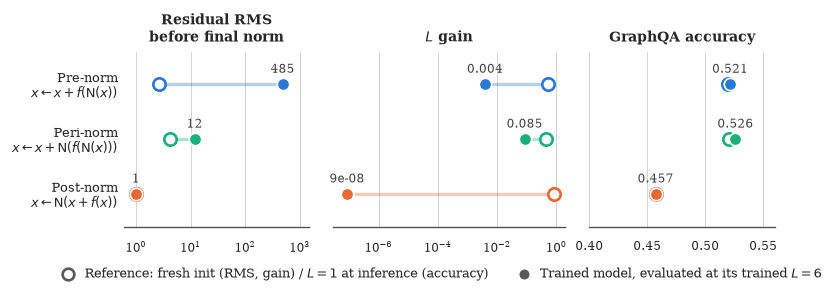

In [38]:
# Categorical color = norm type (validated palette: blue / orange / aqua). Rows carry their name and
# update rule as labels, so identity never relies on color alone.
NORM_ARMS = [
    ("pre", "Pre-norm", r"$x \leftarrow x + f(\mathrm{N}(x))$", "#2a78d6"),
    ("peri", "Peri-norm", r"$x \leftarrow x + \mathrm{N}(f(\mathrm{N}(x)))$", "#1baf7a"),
    ("post", "Post-norm", r"$x \leftarrow \mathrm{N}(x + f(x))$", "#eb6834"),
]


def plot_norm_comparison(fname="recursion_hyp_norms"):
    cell_probe = probe_raw[(probe_raw["H"] == 1) & (probe_raw["L"] == 6) & (probe_raw["role"] == "L")]
    step_mean = cell_probe.groupby(["arm", "init", "stat"])["value"].mean()
    acc = arm_acc.xs((1, 6), level=["H", "L"])

    fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, 1.9), sharey=True,
                             gridspec_kw=dict(wspace=0.12, width_ratios=[1, 1.25, 1]))
    ys = np.arange(len(NORM_ARMS))[::-1]
    for y, (arm, name, rule, color) in zip(ys, NORM_ARMS):
        panels = [
            (axes[0], step_mean[(arm, "fresh", "prenorm_rms")], step_mean[(arm, "trained", "prenorm_rms")]),
            (axes[1], step_mean[(arm, "fresh", "gain")], step_mean[(arm, "trained", "gain")]),
            (axes[2], acc.loc[arm, "acc (L=1)"], acc.loc[arm, "acc"]),
        ]
        for ax, hollow, filled in panels:
            ax.plot([hollow, filled], [y, y], color=color, linewidth=2, alpha=0.35, zorder=2,
                    solid_capstyle="round")
            ax.scatter(hollow, y, s=55, facecolors="white", edgecolors=color, linewidths=1.6, zorder=3)
            ax.scatter(filled, y, s=55, color=color, edgecolors="white", linewidths=1.0, zorder=4)
        # Direct value labels on the trained point only.
        axes[0].annotate(f"{step_mean[(arm, 'trained', 'prenorm_rms')]:.0f}",
                         (step_mean[(arm, "trained", "prenorm_rms")], y), xytext=(0, 7),
                         textcoords="offset points", ha="center", fontsize=7, color="0.25")
        g = step_mean[(arm, "trained", "gain")]
        axes[1].annotate(f"{g:.3f}" if g >= 1e-3 else f"{g:.0e}", (g, y), xytext=(0, 7),
                         textcoords="offset points", ha="center", fontsize=7, color="0.25")
        axes[2].annotate(f"{acc.loc[arm, 'acc']:.3f}", (acc.loc[arm, "acc"], y), xytext=(0, 7),
                         textcoords="offset points", ha="center", fontsize=7, color="0.25")

    axes[0].set_yticks(ys, [f"{name}\n{rule}" for _, name, rule, _ in NORM_ARMS], fontsize=7.5)
    axes[0].set_ylim(-0.6, len(NORM_ARMS) - 0.4)
    axes[0].set_xscale("log")
    axes[0].set_xlim(0.6, 1500)
    axes[0].set_title("Residual RMS\nbefore final norm", fontsize=8.5)
    axes[1].set_xscale("log")
    axes[1].set_xlim(3e-8, 2)
    axes[1].set_title("$L$ gain", fontsize=8.5)
    axes[2].set_xlim(0.40, 0.56)
    axes[2].set_title("GraphQA accuracy", fontsize=8.5)
    for ax in axes:
        ax.tick_params(axis="x", labelsize=7)
        ax.grid(axis="y", visible=False)
        sns.despine(ax=ax, left=True)
    axes[0].tick_params(axis="y", length=0)

    # Marker legend in neutral grey: fill encodes the reference vs the trained model, color the norm.
    marker = dict(marker="o", linestyle="none", markersize=7, color="0.35")
    handles = [
        mpl.lines.Line2D([], [], markerfacecolor="white", markeredgewidth=1.6, **marker,
                         label="Reference: fresh init (RMS, gain) / $L = 1$ at inference (accuracy)"),
        mpl.lines.Line2D([], [], markeredgecolor="white", **marker,
                         label="Trained model, evaluated at its trained $L = 6$"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=7.5,
               handletextpad=0.3, columnspacing=1.8)
    save_fig(fig, fname)
    plt.show()


plot_norm_comparison()

**Reading.** Only the norm placement changes between the rows, and it shows in the first two panels:

- *Pre-norm.* Sublayer outputs are added unnormalised, so the stream grows to RMS 485. The final norm
  divides the incoming state by the same factor, and the $L$ gain falls from 0.51 at initialisation to
  0.004.
- *Peri-norm.* Every sublayer output is normalised before it is added. Twelve sublayers can then grow
  the stream to at most $\approx 12$, and the gain settles at 0.085, close to $1/12$: the state survives
  through the residual path.
- *Post-norm.* The stream is renormalised after every sublayer (RMS 1 by construction). The incoming
  state is shrunk at each of the 12 renormalisations, and the gain falls from 0.84 to $\approx 10^{-7}$.

The third panel is the RQ2.3.3 result. Peri-norm keeps the state alive, yet its accuracy (0.526)
matches pre-norm (0.521), and dropping to $L = 1$ at inference costs at most 0.5 points in all three
rows. Post-norm is the only placement that changes accuracy, and it lowers it.

### RQ2.3.1b — Per-task, with the pretrained HRM-Text-1B as reference

The per-task heatmap of RQ2.3.1 with one extra column on the left: **HRM-Text-1B**, the pretrained
checkpoint fine-tuned on the same GraphQA training set (RQ1, direct regime). This separates tasks that
cannot be learned in this text format from tasks that cannot be learned *from scratch at size B*.
The leftmost column, **freq. rule**, always answers the task's most frequent training answer
(RQ2.4.a, `scripts/answer_prior_baseline.py`; here pooled over val + test like the size-B cells): a
variant that does not beat it has learned nothing beyond the answer distribution.

Caveats: the 1B score is exact match on the GraphQA **val** split, computed by the fine-tuning
trainer (Graph-Representation-Learning-for-LLM). The size-B cells are val + test pooled and scored
by `scripts/eval_graphqa.py`. Both use the same `baseline/standard` data and the same 11 tasks, so
compare task by task, approximately, not sample by sample.

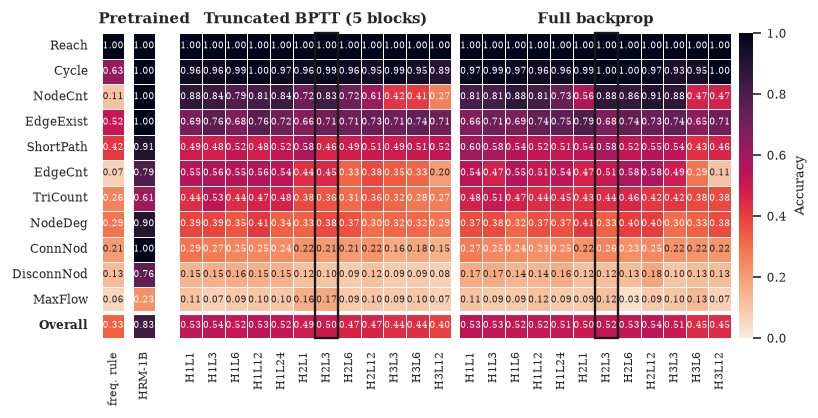

,freq. rule,HRM-Text-1B,"size B, best cell","size B, mean"
Reachability,1.000,1.000,1.000,1.000
CycleCheck,0.627,1.000,1.000,0.969
NodeCount,0.109,1.000,0.906,0.716
EdgeExistence,0.516,1.000,0.790,0.714
ShortestPath,0.418,0.909,0.604,0.519
EdgeCount,0.073,0.793,0.582,0.453
TriangleCounting,0.259,0.610,0.531,0.414
NodeDegree,0.293,0.905,0.415,0.356
ConnectedNodes,0.205,1.000,0.295,0.229
DisconnectedNodes,0.128,0.757,0.179,0.130


In [39]:
# Same heatmaps as `plot_task_cells`, plus one-column reference panels on the left: the
# always-most-frequent-answer rule (RQ2.4.a) and the pretrained 1B.
hrm1b_by_task = id_by_task.loc[HRM_ARCH].rename(lambda c: c.removeprefix("val/exact_match_")).astype(float)
# Rule accuracy pooled over val + test, like the size-B cells (scripts/answer_prior_baseline.py).
prior_vt = pd.read_csv(RESULTS_DIR / "answer-prior-baseline.csv").query("split in ['val', 'test']")
rule_by_task = ((prior_vt["prior_acc"] * prior_vt["n"]).groupby(prior_vt["task"]).sum()
                / prior_vt.groupby("task")["n"].sum())

# Last heatmap row: overall accuracy over all samples (correct / n, so weighted by task size).
OVERALL = "Overall"
rule_overall = (prior_vt["prior_acc"] * prior_vt["n"]).sum() / prior_vt["n"].sum()
hrm1b_overall = float(perf_id.set_index("model").loc[HRM_ARCH, "val/exact_match"])


def with_overall(grid, overall):
    """`grid` (task x column) in TASK_ORDER plus an Overall row; `overall`: column -> value."""
    return pd.concat([grid.reindex(TASK_ORDER), pd.Series(overall).reindex(grid.columns).to_frame(OVERALL).T])


def style_overall(ax, first):
    """White gap above the Overall row; its label in bold."""
    ax.axhline(len(TASK_ORDER), color="white", linewidth=2.5)
    if first:
        ax.get_yticklabels()[-1].set_fontweight("bold")


def plot_task_cells_with_ref(refs, fname="recursion_hyp_per_task_1b"):
    """`refs`: list of (title, per-task Series, column label, overall), one single-column panel each."""
    regimes = [TRUNC_BP, FULL_BP]
    grids = {}
    for regime in regimes:
        sub = task_cells[task_cells["bp"] == regime].sort_values(["H", "L"])
        sub = sub.assign(cell=[f"H{h}L{l}" for h, l in zip(sub["H"], sub["L"])])
        order = list(dict.fromkeys(sub["cell"]))
        tot = sub.groupby("cell")[["correct", "n"]].sum()
        grids[regime] = with_overall(sub.pivot(index="group", columns="cell", values="accuracy")[order],
                                     tot["correct"] / tot["n"])
    # Reference columns | spacer | truncated | full backprop | colorbar.
    widths = [1] * len(refs) + [0.35] + [g.shape[1] for g in grids.values()] + [0.6]
    fig = plt.figure(figsize=(PAGE_W, 3.3))
    gs = fig.add_gridspec(1, len(widths), width_ratios=widths, wspace=0.08)
    cbar_ax = fig.add_subplot(gs[0, -1])
    panels = [(gs[0, k], with_overall(ref.to_frame(label), {label: overall}), title)
              for k, (title, ref, label, overall) in enumerate(refs)] + [
        (gs[0, len(refs) + 1 + j], grids[regime], regime) for j, regime in enumerate(regimes)]
    for j, (spec, grid, title) in enumerate(panels):
        ax = fig.add_subplot(spec)
        last = j == len(panels) - 1
        sns.heatmap(grid, ax=ax, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                    linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
                    cbar=last, cbar_ax=cbar_ax if last else None,
                    cbar_kws={"label": "Accuracy"} if last else None)
        if j and "H2L3" in grid.columns:  # the 1B's depth
            ax.add_patch(mpl.patches.Rectangle((list(grid.columns).index("H2L3"), 0), 1, len(grid), fill=False,
                                               edgecolor="0.1", linewidth=1.4, clip_on=False, zorder=3))
        ax.set_facecolor("0.90")
        ax.grid(False)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6.5)
        ax.set_yticklabels([TASK_ABBREV.get(t, t) for t in TASK_ORDER] + [OVERALL] if j == 0 else [], fontsize=7)
        style_overall(ax, j == 0)
        if j:
            ax.tick_params(axis="y", length=0)
    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_task_cells_with_ref([("", rule_by_task, "freq. rule", rule_overall),
                          ("Pretrained", hrm1b_by_task, "HRM-1B", hrm1b_overall)])

# Per task: the rule and the 1B next to the best and the mean from-scratch cell.
pd.DataFrame({
    "freq. rule": rule_by_task,
    HRM_ARCH: hrm1b_by_task,
    "size B, best cell": task_spread["max"],
    "size B, mean": task_spread["mean"],
}).reindex(TASK_ORDER).round(3)

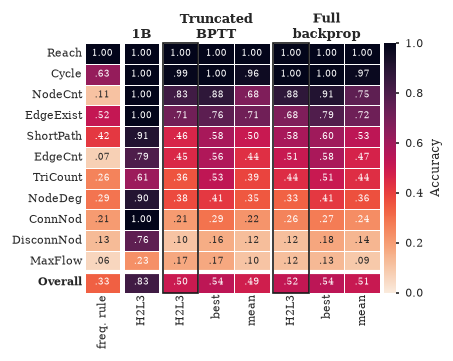

In [40]:
# Single-column version of `recursion_hyp_per_task_1b` (rule column untitled, label in the tick).
# Each from-scratch regime is condensed to
# its H2L3 cell (the 1B's depth, outlined), and its best and mean accuracy over all (H, L) cells.
def short_fmt(v):
    return "" if pd.isna(v) else f"{v:.2f}".removeprefix("0")


def plot_compact_task_panels(panels, fname, cbar_label, outline="H2L3", height=2.7):
    """`panels`: list of (title, task x column frame). `outline` is boxed in multi-column panels."""
    widths = [g.shape[1] for _, g in panels] + [0.35]
    fig = plt.figure(figsize=(COL_W, height))
    gs = fig.add_gridspec(1, len(widths), width_ratios=widths, wspace=0.06)
    cbar_ax = fig.add_subplot(gs[0, -1])
    for j, (title, grid) in enumerate(panels):
        ax = fig.add_subplot(gs[0, j])
        grid = grid.reindex(TASK_ORDER + [OVERALL]).astype(float)
        last = j == len(panels) - 1
        sns.heatmap(grid, ax=ax, annot=grid.map(short_fmt), fmt="", cmap="rocket_r", vmin=0, vmax=1,
                    linewidths=0.3, linecolor="white", annot_kws={"fontsize": 5.4},
                    cbar=last, cbar_ax=cbar_ax if last else None,
                    cbar_kws={"label": cbar_label} if last else None)
        if grid.shape[1] > 1 and outline in grid.columns:
            ax.add_patch(mpl.patches.Rectangle((list(grid.columns).index(outline), 0), 1, len(grid),
                                               fill=False, edgecolor="0.1", linewidth=1.0, clip_on=False, zorder=3))
        ax.set_facecolor("0.90")
        ax.grid(False)
        ax.set_title(title, fontsize=7.5, pad=3)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6.5)
        ax.set_yticklabels([TASK_ABBREV.get(t, t) for t in TASK_ORDER] + [OVERALL] if j == 0 else [], fontsize=6.5)
        style_overall(ax, j == 0)
        ax.tick_params(axis="both", length=0, pad=1.5)
    cbar_ax.yaxis.label.set_size(7)
    cbar_ax.tick_params(labelsize=6.5, length=2)
    save_fig(fig, fname)
    plt.show()


def regime_summary(regime):
    """Per task: the H2L3 cell, the best and the mean cell. Overall row: the same over cells' overall."""
    sub = task_cells[task_cells["bp"] == regime]
    by_task = sub.groupby("group")["accuracy"]
    tot = sub.groupby(["H", "L"])[["correct", "n"]].sum()
    cell_overall = tot["correct"] / tot["n"]
    return with_overall(
        pd.DataFrame({"H2L3": sub[(sub["H"] == 2) & (sub["L"] == 3)].set_index("group")["accuracy"],
                      "best": by_task.max(), "mean": by_task.mean()}),
        {"H2L3": cell_overall[(2, 3)], "best": cell_overall.max(), "mean": cell_overall.mean()})


plot_compact_task_panels(
    [("", with_overall(rule_by_task.to_frame("freq. rule"), {"freq. rule": rule_overall})),
     ("1B", with_overall(hrm1b_by_task.to_frame("H2L3"), {"H2L3": hrm1b_overall})),
     ("Truncated\nBPTT", regime_summary(TRUNC_BP)),
     ("Full\nbackprop", regime_summary(FULL_BP))],
    "recursion_hyp_per_task_1b_compact", "Accuracy",
)


**Reading.**

- *The floor tasks are learnable in this format.* The pretrained 1B solves ConnectedNodes (1.00,
  against at most 0.30 for any size-B cell) and most of DisconnectedNodes (0.76 vs 0.18). It is also
  far ahead on NodeDegree (0.91 vs 0.42) and ShortestPath (0.91 vs 0.60).
- *MaximumFlow is the only task that stays low for everyone* (1B 0.23, size B at most 0.17). That is
  consistent with the edge capacities missing from this split.
- *So "floor" in RQ2.3.1 is a property of the from-scratch size-B models, not of the tasks.* The H3
  statement needs that qualification: at this data scale, no recursion setting lifts the tasks the
  size-B models can't learn, but the tasks themselves are solvable.
- *At the 1B's own depth the gap is unchanged.* The outlined $H2L3$ columns are size B at the 1B's
  $(H, L)$: 0.50 with truncated BPTT, which gives the same L gradient budget as the 1B's pretraining
  (the last $H$ cycle's 3 L steps), and 0.52 with full backprop, pooled over val + test. Both are in line
  with the other $H = 2$ cells (0.47–0.54), and the lookup tasks stay at the floor where the 1B is near
  the ceiling (truncated / full backprop vs 1B): ConnectedNodes 0.21 / 0.26 vs 1.00, DisconnectedNodes
  0.10 / 0.12 vs 0.76, NodeDegree 0.38 / 0.33 vs 0.90. The gap is not a depth mismatch.
- *What this does not separate.* The 1B differs in pretraining, parameter count (1B vs size B) and
  fine-tuning recipe all at once. The gap can't be attributed to any one of them, and in particular
  it says nothing about recursion depth.

# RQ2.4 — Does a pretrained HRM use its recursion? (hypotheses a–e)

RQ2.1–RQ2.3 find no recursion effect in HRM trained **from scratch**: accuracy is flat in $L$, drops with
$H$, the trained $L$ block ignores its incoming state, and neither full backprop, other norms, smaller
modules nor 300× more data changes that. RQ2.3.1b shows the pretrained HRM-Text-1B far ahead on the
same tasks. This section asks whether the **pretrained** model uses its recursion, with five checks:

| | Question | Runs |
|---|---|---|
| **a** | Do the from-scratch models beat always giving the most frequent answer? | that rule's accuracy per task vs every from-scratch eval |
| **b** | Does the fine-tuned 1B depend on its depth? | each fine-tuned 1B (trained at $H2L3$) evaluated at 9 other $(H, L)$, no training |
| **c** | Is its recurrent state alive? | gain probe of RQ2.3.3 on the raw, random-init and fine-tuned 1B |
| **d** | Which depth is best when fine-tuning from the pretrained weights? | GraphQA fine-tunes at $H1L1$, $H2L1$, $H1L6$, $H2L6$, $H3L3$, $H4L3$ |
| **e** | Same, once the task is learned at $H2L3$? | the GraphQA $H2L3$ fine-tune continued at $H1L1$, $H2L6$, $H3L3$ |

**Setup.** HRM-Text-1B: $H2L3$, 16 layers per module, hidden 1536, 1.18B parameters. Fine-tuning and
evaluation use the pipeline of the RQ1 1B results (Graph-Representation-Learning-for-LLM, branch
`cross-repo`): constant LR $5\cdot10^{-5}$, batch 32, gradient clipping 1.0, early stopping on val loss,
BPTT through the $L$ steps of the last $H$ cycle (the pretraining rule). The reference is the GraphQA
$H2L3$ fine-tune (W&B run `8dfnfqn3`). Scores are **teacher-forced exact match on the test split**
($n = 385$ for GraphQA, one SE $\approx 1.9$ points at 0.83), not the greedy-generation accuracy of
RQ2.1–RQ2.3: compare numbers within this section only. A depth is also counted in **stack applications**
per token, $H \cdot (L + 1)$ (each one 16 layers; $H2L3$ = 8). W&B project `HRM-Pretrained-Recursion`,
exported by `scripts/pull_pretrained_recursion.py` and `scripts/answer_prior_baseline.py`.

In [41]:
# Pretrained-recursion runs (W&B HRM-Pretrained-Recursion). Eval rows: b (fine-tuned 1B at another depth),
# d-test / e-test (test score of the d / e checkpoints at their trained depth, at L = 1 and at H2L3).
pr_eval = pd.read_csv(RESULTS_DIR / "pretrained-recursion-eval.csv")
pr_probe = pd.read_csv(RESULTS_DIR / "pretrained-recursion-probe.csv")
pr_curves = pd.read_csv(RESULTS_DIR / "pretrained-recursion-train.csv")
pr_eval = pd.concat([pr_eval, pd.DataFrame({
    "cell": "H" + pr_eval["H"].astype(str) + "L" + pr_eval["L"].astype(str),
    "stacks": pr_eval["H"] * (pr_eval["L"] + 1)})], axis=1)

PR_DATASETS = {
    "graphqa": "GraphQA", "metaqa-gold-1": "MetaQA Gold-1", "metaqa-gold-5": "MetaQA Gold-5",
    "metaqa-gold-10": "MetaQA Gold-10", "metaqa-retrieved-1": "MetaQA Retr.-1", "kqapro": "KQA-Pro",
}
# Categorical pair (validated: CVD dE 24.7, normal dE 33.6): d runs blue, e runs orange.
D_COLOR, E_COLOR = "#2a78d6", "#eb6834"

# The reference: the GraphQA H2L3 fine-tune scored at its own depth.
pr_ref = pr_eval.query("exp == 'b' and dataset == 'graphqa' and cell == 'H2L3'").iloc[0]
print(f"{len(pr_eval)} eval runs, {pr_probe['run'].nunique()} probed checkpoints, "
      f"{pr_curves['run'].nunique()} fine-tunes; reference GraphQA test EM {pr_ref['exact_match']:.3f}")

80 eval runs, 18 probed checkpoints, 10 fine-tunes; reference GraphQA test EM 0.834


## RQ2.4.a — Answer prior: what the from-scratch models learned

Can the from-scratch models do better than a rule that ignores the graph? The rule: for each task, take the
answer that is most frequent in the GraphQA training set ("yes" for Reachability, "0" for ConnectedNodes, …)
and give it to every test question. A model that scores like this rule has learned how often each answer
occurs, not how to read the graph. Columns:

- *most frequent answer*, and how many *distinct answers* the test split has for the task;
- *always that answer*: test accuracy of the rule;
- *size B, no pretraining*: the ~0.3B HRM models of RQ2.1–RQ2.3, trained from random weights on GraphQA
  only (no pretraining, so no fine-tuning either). Mean over 44 runs — every $(H, L)$, gradient regime and
  norm arm of RQ2.1''–RQ2.3 plus the 1M-sample runs — on the test split, diverged $H \geq 4$ runs excluded;
- *size B, share = that answer*: the share of their predictions that are exactly the most frequent answer;
- *HRM-1B, pretrained + fine-tuned*: the pretrained 1B fine-tuned on the same 3,080 GraphQA samples, at $H2L3$.

In [42]:
prior = pd.read_csv(RESULTS_DIR / "answer-prior-baseline.csv").query("split == 'test'").set_index("task")
prior_runs = pd.read_csv(RESULTS_DIR / "answer-prior-runs.csv")
scratch = prior_runs[(prior_runs["source"] == "from-scratch") & (prior_runs["split"] == "test")
                     & ~prior_runs["diverged"] & ~prior_runs["file"].str.contains("Lov")]
scratch_task = scratch.groupby("task")[["acc", "share_eq_prior"]].mean()

prior_tbl = pd.DataFrame({
    "most frequent answer": prior["prior_answer"],
    "distinct answers": prior["n_unique_gold"],
    "always that answer": prior["prior_acc"],
    "size B, no pretraining": scratch_task["acc"],
    "size B, share = that answer": scratch_task["share_eq_prior"],
    "HRM-1B, pretrained + fine-tuned": pd.Series({t: pr_ref[f"exact_match_{t}"] for t in GRAPH_TASKS}),
}).reindex(TASK_ORDER)
print(f"size B: mean of {scratch['run'].nunique()} runs (greedy-generation accuracy); "
      "HRM-1B: the GraphQA H2L3 fine-tune (teacher-forced exact match)")
prior_tbl.round(3)

size B: mean of 44 runs (greedy-generation accuracy); HRM-1B: the GraphQA H2L3 fine-tune (teacher-forced exact match)


,most frequent answer,distinct answers,always that answer,"size B, no pretraining","size B, share = that answer","HRM-1B, pretrained + fine-tuned"
Reachability,yes,1,1.000,0.999,0.999,1.000
CycleCheck,"yes, there is a cycle",2,0.556,0.947,0.591,1.000
NodeCount,6,11,0.074,0.661,0.080,1.000
EdgeExistence,no,2,0.588,0.681,0.516,1.000
ShortestPath,1,4,0.412,0.563,0.530,0.941
EdgeCount,6,20,0.038,0.394,0.075,0.577
TriangleCounting,0,26,0.250,0.357,0.323,0.525
NodeDegree,1,15,0.225,0.328,0.421,0.925
ConnectedNodes,0,25,0.206,0.266,0.274,0.971
DisconnectedNodes,no nodes,37,0.073,0.081,0.149,0.976


**Reading.**

- *Reachability measures nothing.* Every test answer is "yes", so always answering "yes" scores 1.000.
  CycleCheck and EdgeExistence are binary; always giving the most frequent answer scores 0.56 and 0.59.
- *On the floor tasks, size B is no better than the rule.* ConnectedNodes 0.27 vs 0.21 for the rule,
  DisconnectedNodes 0.08 vs 0.07, MaximumFlow 0.08 vs 0.06; NodeDegree 0.33 vs 0.23, with 42% of its
  predictions equal to the most frequent answer "1".
  On these tasks the from-scratch models learned the answer distribution, not the graph.
- *The pretrained 1B solves them* (ConnectedNodes 0.97, DisconnectedNodes 0.98, NodeDegree 0.93), except
  MaximumFlow (0.21), whose split gives no edge capacities.

**Verdict (a).** The "floor" of RQ2.3.1 is the level of always giving the most frequent answer (the
"answer prior"). Recursion had nothing to act on in these models:
they never learned to read the edges that the lookup tasks need.

## RQ2.4.b — Depth override: does the fine-tuned 1B depend on its depth?

Each 1B fine-tune (trained at $H2L3$) is evaluated, without retraining, at 9 depths. Color: exact match
relative to the trained depth (outlined); numbers: raw exact match.

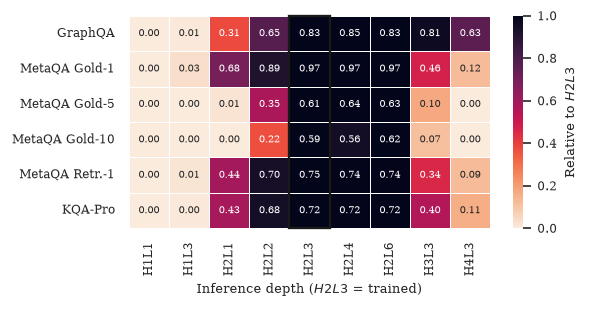

cell,H1L1,H1L3,H2L1,H2L2,H2L3,H2L4,H2L6,H3L3,H4L3
dataset,,,,,,,,,
GraphQA,0.0,0.005,0.314,0.647,0.834,0.847,0.831,0.805,0.634
MetaQA Gold-1,0.0,0.032,0.677,0.890,0.968,0.967,0.968,0.460,0.120
MetaQA Gold-5,0.0,0.000,0.013,0.351,0.608,0.635,0.633,0.104,0.000
MetaQA Gold-10,0.0,0.000,0.000,0.216,0.586,0.558,0.617,0.067,0.000
MetaQA Retr.-1,0.0,0.012,0.441,0.701,0.746,0.742,0.741,0.339,0.092
KQA-Pro,0.0,0.004,0.426,0.684,0.723,0.720,0.724,0.405,0.115


In [43]:
B_CELLS = ["H1L1", "H1L3", "H2L1", "H2L2", "H2L3", "H2L4", "H2L6", "H3L3", "H4L3"]
b_raw = (pr_eval[pr_eval["exp"] == "b"].pivot(index="dataset", columns="cell", values="exact_match")
         .reindex(index=list(PR_DATASETS), columns=B_CELLS))
b_rel = b_raw.div(b_raw["H2L3"], axis=0)


def plot_depth_override(fname="pretrained_depth_override"):
    fig, ax = plt.subplots(figsize=(COL_W * 1.45, 2.3))
    sns.heatmap(b_rel.clip(upper=1), ax=ax, annot=b_raw, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                linewidths=0.4, linecolor="white", annot_kws={"fontsize": 6},
                cbar_kws={"label": "Relative to $H2L3$"})
    ax.add_patch(mpl.patches.Rectangle((B_CELLS.index("H2L3"), 0), 1, len(b_raw), fill=False,
                                       edgecolor="0.1", linewidth=1.4, clip_on=False))
    ax.grid(False)
    ax.set_xlabel("Inference depth ($H2L3$ = trained)", fontsize=8)
    ax.set_ylabel("")
    ax.set_xticklabels(B_CELLS, rotation=90, fontsize=7)
    ax.set_yticklabels([PR_DATASETS[d] for d in b_raw.index], fontsize=7, rotation=0)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7)
    cbar.ax.yaxis.label.set_size(8)
    save_fig(fig, fname)
    plt.show()


plot_depth_override()
b_raw.rename(index=PR_DATASETS).round(3)

**Reading.**

- *One $H$ cycle destroys every fine-tune.* $H1L1$ scores 0.000 on all six benchmarks and $H1L3$ at most 0.03.
- *Fewer $L$ steps degrade it gradually.* GraphQA: 0.31 at $H2L1$, 0.65 at $H2L2$, 0.83 at $H2L3$. Going from
  $L = 3$ to $L = 1$ costs 52 points on GraphQA and 29–30 on MetaQA Gold-1 / KQA-Pro, and brings the
  multi-answer Gold-5 / Gold-10 to 0. The same test on the from-scratch model (RQ2.3.3, $L = 6 \to 1$) cost
  at most 0.5 points.
- *More $L$ steps change nothing.* $H2L4$ and $H2L6$ stay within 0.031 of $H2L3$ on every benchmark: the
  $L$ loop converges to a fixed point, so extra steps neither help nor hurt.
- *More $H$ cycles hurt*, except on GraphQA: $H3L3$ falls to 0.07–0.46 on the KGQA benchmarks
  (GraphQA 0.81) and $H4L3$ to 0.00–0.12 (GraphQA 0.63).

**Verdict (b).** The pretrained model depends on its recursion: it needs its two $H$ cycles and at least
two to three $L$ steps. This is a zero-shot change of depth, out of distribution for the weights, so it shows
dependence, not the best depth — d and e retrain at the new depth.

## RQ2.4.c — Gain probe: is the recurrent state alive?

Same probe as RQ2.3.3 (fp32, $\varepsilon = 1$, 12 val samples): the gain of the $L$ block to a change of its
incoming state, and the residual RMS before the stack's final norm. Hollow (size B): random initialisation;
filled: trained. Size B is the pre-norm $H1L6$ full-backprop model of RQ2.3.3.

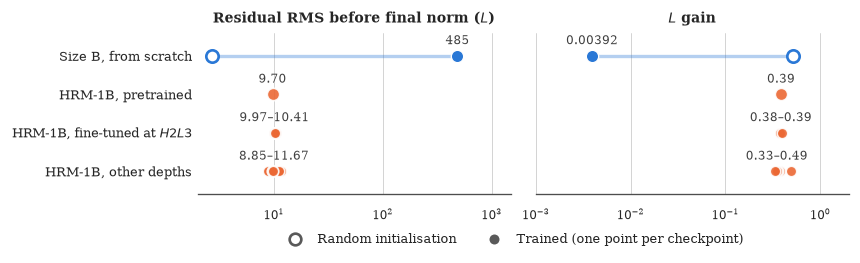

gain        gain_H             rms         
                                  min    max    min    max      min      max
group                                                                       
HRM-1B, pretrained              0.385  0.385  0.278  0.278    9.704    9.704
HRM-1B, fine-tuned at $H2L3$    0.375  0.391  0.321  0.370    9.966   10.412
HRM-1B, other depths            0.331  0.486  0.310  0.343    8.846   11.675
Size B, from scratch (trained)  0.004  0.004    NaN    NaN  484.885  484.885

In [44]:
# Size-B reference (RQ2.3.3): pre-norm H1L6, full backprop, L role.
sizeb = (probe_raw[(probe_raw["arm"] == "pre") & (probe_raw["H"] == 1) & (probe_raw["L"] == 6)
                   & (probe_raw["role"] == "L")].groupby(["init", "stat"])["value"].mean())

# HRM-1B: one point per probed checkpoint. L gain over steps >= 1 (step 0 reads the constant z_L_init,
# and H1L1 models have no other L step); residual RMS over all L steps.
l_rows = pr_probe[pr_probe["role"] == "L"]
per_ckpt = pd.DataFrame({"gain": l_rows.groupby("run")["gain"].mean(),
                         "rms": l_rows.groupby("run")["prenorm_rms"].mean(),
                         "gain_H": pr_probe[pr_probe["role"] == "H"].groupby("run")["gain"].mean()})
PROBE_GROUPS = ["HRM-1B, pretrained", "HRM-1B, fine-tuned at $H2L3$", "HRM-1B, other depths"]


def probe_group(run):
    if run.endswith("pretrained-fresh-H2L3"):
        return None  # the 1B architecture at random init: probed, not plotted
    if run.startswith("c-probe-pretrained-trained"):
        return PROBE_GROUPS[0]
    if run.startswith("c-probe-ft-"):
        return PROBE_GROUPS[1]
    return PROBE_GROUPS[2]


per_ckpt["group"] = per_ckpt.index.map(probe_group)
per_ckpt = per_ckpt.dropna(subset=["group"])


def plot_pretrained_gain(fname="pretrained_gain"):
    rows = ["Size B, from scratch"] + PROBE_GROUPS
    ys = dict(zip(rows, np.arange(len(rows))[::-1]))
    fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, 1.75), sharey=True, gridspec_kw=dict(wspace=0.08))
    for ax, stat, col in ((axes[0], "prenorm_rms", "rms"), (axes[1], "gain", "gain")):
        y = ys["Size B, from scratch"]
        ax.plot([sizeb[("fresh", stat)], sizeb[("trained", stat)]], [y, y], color=D_COLOR, lw=2, alpha=0.35)
        ax.scatter(sizeb[("fresh", stat)], y, s=55, facecolors="white", edgecolors=D_COLOR, linewidths=1.6, zorder=3)
        ax.scatter(sizeb[("trained", stat)], y, s=55, color=D_COLOR, edgecolors="white", zorder=4)
        ax.annotate(f"{sizeb[('trained', stat)]:.3g}", (sizeb[("trained", stat)], y), xytext=(0, 7),
                    textcoords="offset points", ha="center", fontsize=7, color="0.25")
        for group in PROBE_GROUPS:
            vals = per_ckpt.loc[per_ckpt["group"] == group, col].dropna()
            ax.scatter(vals, np.full(len(vals), ys[group]), s=40 if len(vals) > 1 else 55,
                       color=E_COLOR, edgecolors="white", linewidths=1.0, alpha=0.9, zorder=3)
            label = f"{vals.median():.2f}" if len(vals) == 1 else f"{vals.min():.2f}–{vals.max():.2f}"
            ax.annotate(label, (vals.median(), ys[group]), xytext=(0, 7), textcoords="offset points",
                        ha="center", fontsize=7, color="0.25")
        ax.set_xscale("log")
        ax.grid(axis="y", visible=False)
        ax.tick_params(axis="x", labelsize=7)
        sns.despine(ax=ax, left=True)
    axes[0].set_xlim(2, 1500)
    axes[0].set_title("Residual RMS before final norm ($L$)", fontsize=8.5)
    axes[1].set_xlim(1e-3, 2)
    axes[1].set_title("$L$ gain", fontsize=8.5)
    axes[0].set_yticks(list(ys.values()), list(ys.keys()), fontsize=7.5)
    axes[0].set_ylim(-0.6, len(rows) - 0.4)
    axes[0].tick_params(axis="y", length=0)
    marker = dict(marker="o", linestyle="none", markersize=7, color="0.35")
    fig.legend(handles=[
        mpl.lines.Line2D([], [], markerfacecolor="white", markeredgewidth=1.6, **marker, label="Random initialisation"),
        mpl.lines.Line2D([], [], markeredgecolor="white", **marker, label="Trained (one point per checkpoint)"),
    ], loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=7.5)
    save_fig(fig, fname)
    plt.show()


plot_pretrained_gain()
gain_summary = per_ckpt.groupby("group")[["gain", "gain_H", "rms"]].agg(["min", "max"]).reindex(PROBE_GROUPS)
gain_summary.loc["Size B, from scratch (trained)"] = [sizeb[("trained", "gain")]] * 2 + [np.nan] * 2 + [sizeb[("trained", "prenorm_rms")]] * 2
gain_summary.round(3)

**Reading.**

- *The pretrained $L$ block responds to its state.* $L$ gain 0.385 for the raw pretrained model, 0.38–0.39
  for the six fine-tunes at $H2L3$, 0.33–0.49 for the fine-tunes at other depths; residual RMS 9–12.
  The from-scratch size-B block: gain 0.004, RMS 485. The $H$ block of the 1B keeps a gain of 0.28–0.37.
- *Fine-tuning does not wash it out.* Every fine-tune, at every depth, stays at the gain of the pretrained
  model.
- *Not the block type alone.* Both models use pre-norm blocks with the final norm inside the recurrence, so
  the washout of RQ2.3.3 comes from how the model was trained. The 1B also differs (gated attention, an
  embedding scale of 39, 16-layer modules), so the comparison is not of identical architectures.

**Verdict (c).** In the pretrained model the recurrent state is alive, before and after fine-tuning.

## RQ2.4.d / e — Fine-tuning at another depth

**d**: the pretrained weights fine-tuned on GraphQA directly at another depth ($H1L1$ twice). **e**: the
GraphQA $H2L3$ fine-tune continued at another depth, validated before its first step (= the zero-shot
override of b) and every half epoch. Left: test exact match at the trained depth against the number of
stack applications. Right: the e validation curves.

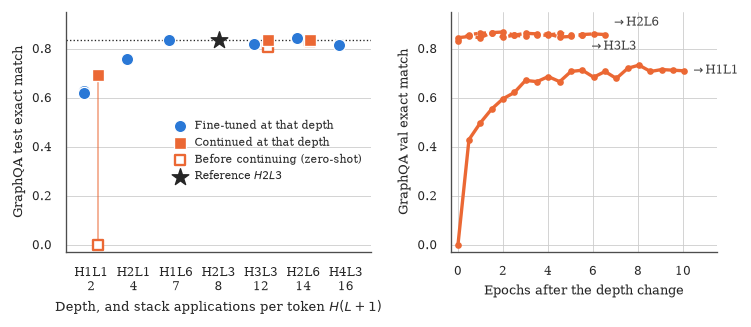

,stacks,trained depth,L = 1,at H2L3,zero-shot
d-graphqa-H1L1-rep2,2.0,0.618,NaN,0.384,NaN
d-graphqa-H1L1,2.0,0.626,NaN,0.405,NaN
e-graphqa-to-H1L1,2.0,0.691,NaN,0.774,0.000
d-graphqa-H2L1,4.0,0.758,NaN,0.629,NaN
d-graphqa-H1L6,7.0,0.834,0.226,0.719,NaN
reference (H2L3),8.0,0.834,0.314,0.834,NaN
d-graphqa-H3L3,12.0,0.818,0.392,0.756,NaN
e-graphqa-to-H3L3,12.0,0.834,0.460,0.821,0.805
e-graphqa-to-H2L6,14.0,0.836,0.296,0.829,0.831
d-graphqa-H2L6,14.0,0.842,0.332,0.787,NaN


In [45]:
own = pr_eval[pr_eval["exp"].isin(["d-test", "e-test"]) & (pr_eval["H"] == pr_eval["trained_H"])
              & (pr_eval["L"] == pr_eval["trained_L"])]
d_pts, e_pts = own[own["exp"] == "d-test"], own[own["exp"] == "e-test"]
b_graphqa = pr_eval.query("exp == 'b' and dataset == 'graphqa'").set_index("cell")
STEPS_PER_EPOCH = 3080 / 32  # GraphQA train samples / effective batch


def plot_finetune_depth(fname="pretrained_finetune_depth"):
    fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, 2.6), gridspec_kw=dict(wspace=0.28, width_ratios=[1.15, 1]))
    ax = axes[0]
    # One evenly spaced slot per depth, ordered by stack applications; d left, e right of the slot.
    depths = (pd.concat([d_pts[["cell", "stacks"]], e_pts[["cell", "stacks"]],
                         pd.DataFrame({"cell": ["H2L3"], "stacks": [8]})])
              .drop_duplicates().sort_values("stacks"))
    slot = {c: i for i, c in enumerate(depths["cell"])}
    dodge = 0.16
    ax.scatter(d_pts["cell"].map(slot) - dodge, d_pts["exact_match"], s=55, color=D_COLOR, edgecolors="white",
               zorder=4, label="Fine-tuned at that depth")
    for _, row in e_pts.iterrows():
        x, zero = slot[row["cell"]] + dodge, b_graphqa.loc[row["cell"], "exact_match"]
        ax.plot([x, x], [zero, row["exact_match"]], color=E_COLOR, lw=1.2, alpha=0.5, zorder=2)
        ax.scatter(x, zero, s=40, marker="s", facecolors="white", edgecolors=E_COLOR, linewidths=1.4, zorder=3)
    ax.scatter(e_pts["cell"].map(slot) + dodge, e_pts["exact_match"], s=45, marker="s", color=E_COLOR,
               edgecolors="white", zorder=4, label="Continued at that depth")
    ax.scatter([], [], s=40, marker="s", facecolors="white", edgecolors=E_COLOR, linewidths=1.4,
               label="Before continuing (zero-shot)")
    ax.scatter(slot["H2L3"], pr_ref["exact_match"], s=110, marker="*", color="0.15", zorder=5,
               label="Reference $H2L3$")
    ax.axhline(pr_ref["exact_match"], color="0.15", lw=0.8, ls=":", zorder=1)
    ax.set_xticks(range(len(slot)), [f"{c}\n{s}" for c, s in zip(depths["cell"], depths["stacks"])], fontsize=7)
    ax.set_xlim(-0.6, len(slot) - 0.4)
    ax.set_ylim(-0.03, 0.95)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("Depth, and stack applications per token $H(L+1)$", fontsize=8)
    ax.set_ylabel("GraphQA test exact match", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5, loc="center right", bbox_to_anchor=(1, 0.42), handletextpad=0.3)

    ax = axes[1]
    styles = {"H1L1": "-", "H2L6": "--", "H3L3": ":"}
    label_dy = {"H1L1": 0, "H2L6": 7, "H3L3": -7}
    for run, sub in pr_curves[pr_curves["exp"] == "e"].groupby("run"):
        cell = run.removeprefix("e-graphqa-to-").removesuffix("-id")
        sub = sub.sort_values("step")
        x = sub["step"] / STEPS_PER_EPOCH
        ax.plot(x, sub["exact_match"], color=E_COLOR, lw=2, ls=styles[cell], marker="o", markersize=3)
        ax.annotate(f"$\\to${cell}", (x.iloc[-1], sub["exact_match"].iloc[-1]), xytext=(4, label_dy[cell]),
                    textcoords="offset points", va="center", fontsize=7, color="0.25")
    ax.set_xlabel("Epochs after the depth change", fontsize=8)
    ax.set_ylabel("GraphQA val exact match", fontsize=8)
    ax.set_ylim(-0.03, 0.95)
    ax.set_xlim(-0.3, 11.5)
    ax.tick_params(labelsize=7)
    for a in axes:
        sns.despine(ax=a)
    save_fig(fig, fname)
    plt.show()


plot_finetune_depth()

# Test exact match per fine-tune: at its trained depth, with L = 1 at inference, and at H2L3.
def at(sub, cell):
    hit = sub[sub["cell"] == cell]["exact_match"]
    return hit.iloc[0] if len(hit) else np.nan


rows = {}
for source, sub in pr_eval[pr_eval["exp"].isin(["d-test", "e-test"])].groupby("source"):
    H, L = sub["trained_H"].iloc[0], sub["trained_L"].iloc[0]
    rows[source] = {"stacks": H * (L + 1), "trained depth": at(sub, f"H{H}L{L}"),
                    "L = 1": at(sub, f"H{H}L1") if L > 1 else np.nan, "at H2L3": at(sub, "H2L3"),
                    "zero-shot": b_graphqa["exact_match"].get(f"H{H}L{L}") if source.startswith("e-") else np.nan}
rows["reference (H2L3)"] = {"stacks": 8, "trained depth": pr_ref["exact_match"],
                            "L = 1": b_graphqa.loc["H2L1", "exact_match"], "at H2L3": pr_ref["exact_match"],
                            "zero-shot": np.nan}
finetune_tbl = pd.DataFrame(rows).T.sort_values(["stacks", "trained depth"])
finetune_tbl.round(3)

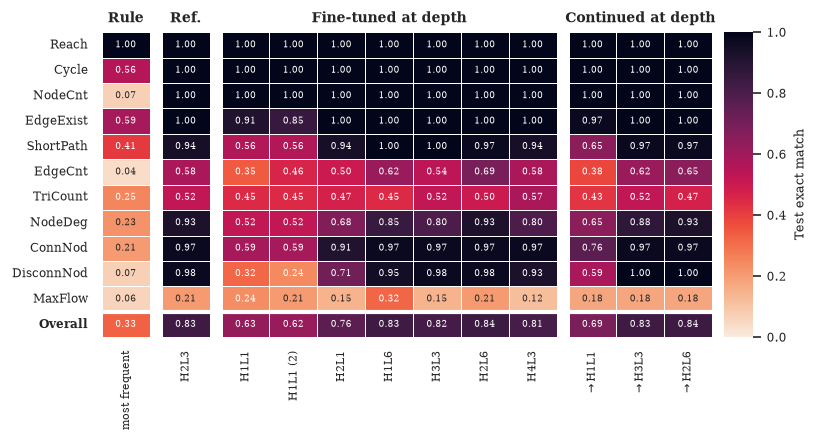

In [46]:
# Per task, at the trained depth: always-most-frequent-answer rule | reference | d | e. Same colormap as
# the other task heatmaps.
def task_col(sub):
    """Per-task exact match plus the overall one (all test samples) as the Overall row."""
    return pd.Series({t: sub[f"exact_match_{t}"].iloc[0] for t in GRAPH_TASKS} | {OVERALL: sub["exact_match"].iloc[0]})


# The rule on the test split, pooled over all test samples for its Overall row.
rule_test = with_overall(prior["prior_acc"].to_frame("most frequent"),
                         {"most frequent": (prior["prior_acc"] * prior["n"]).sum() / prior["n"].sum()})


D_ORDER = ["d-graphqa-H1L1", "d-graphqa-H1L1-rep2", "d-graphqa-H2L1", "d-graphqa-H1L6", "d-graphqa-H3L3",
           "d-graphqa-H2L6", "d-graphqa-H4L3"]
E_ORDER = ["e-graphqa-to-H1L1", "e-graphqa-to-H3L3", "e-graphqa-to-H2L6"]
d_grid = pd.DataFrame({s.removeprefix("d-graphqa-").replace("-rep2", " (2)"): task_col(own[own["source"] == s])
                       for s in D_ORDER})
e_grid = pd.DataFrame({"$\\to$" + s.removeprefix("e-graphqa-to-"): task_col(own[own["source"] == s]) for s in E_ORDER})


def plot_finetune_tasks(fname="pretrained_finetune_per_task"):
    panels = [("Rule", rule_test), ("Ref.", task_col(pr_ref.to_frame().T).to_frame("H2L3")),
              ("Fine-tuned at depth", d_grid), ("Continued at depth", e_grid)]
    widths = [g.shape[1] for _, g in panels] + [0.6]
    fig = plt.figure(figsize=(PAGE_W, 3.3))
    gs = fig.add_gridspec(1, len(widths), width_ratios=widths, wspace=0.1)
    cbar_ax = fig.add_subplot(gs[0, -1])
    for j, (title, grid) in enumerate(panels):
        ax = fig.add_subplot(gs[0, j])
        last = j == len(panels) - 1
        sns.heatmap(grid.reindex(TASK_ORDER + [OVERALL]), ax=ax, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                    linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
                    cbar=last, cbar_ax=cbar_ax if last else None,
                    cbar_kws={"label": "Test exact match"} if last else None)
        ax.grid(False)
        ax.set_ylabel("")
        ax.set_title(title, fontsize=8.5)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6.5)
        ax.set_yticklabels([TASK_ABBREV.get(t, t) for t in TASK_ORDER] + [OVERALL] if j == 0 else [], fontsize=7)
        style_overall(ax, j == 0)
        if j:
            ax.tick_params(axis="y", length=0)
    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_finetune_tasks()

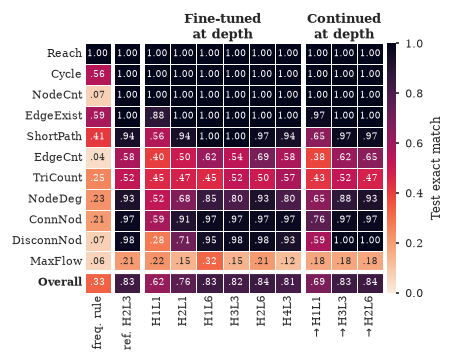

In [47]:
# Single-column version of `pretrained_finetune_per_task` (helper defined with the compact 1B figure).
# The two H1L1 fine-tunes are averaged into one column.
d_compact = d_grid.drop(columns=["H1L1", "H1L1 (2)"]).assign(H1L1=d_grid[["H1L1", "H1L1 (2)"]].mean(axis=1))
d_compact = d_compact[["H1L1"] + [c for c in d_compact.columns if c != "H1L1"]]
plot_compact_task_panels(
    [("", rule_test.set_axis(["freq. rule"], axis=1)),  # single columns: label in the tick, not a title
     ("", task_col(pr_ref.to_frame().T).to_frame("ref. H2L3")),
     ("Fine-tuned\nat depth", d_compact),
     ("Continued\nat depth", e_grid)],
    "pretrained_finetune_per_task_compact", "Test exact match", outline=None,
)


**Reading (d).**

- *Depth matters up to about 7 stack applications, then plateaus.* $H1L1$: 0.626 and 0.618 (two seeds),
  $H2L1$: 0.758, then $H1L6$ 0.834, $H2L3$ 0.834 (reference), $H3L3$ 0.818, $H2L6$ 0.842, $H4L3$ 0.813.
  The plateau spans 3 points ($< 2$ SE): no depth beats the reference.
- *$L$ substitutes for $H$.* $H1L6$ (one $H$ cycle, 7 stack applications) equals $H2L3$ (8). What counts is
  the number of applications, not their split between $H$ and $L$.
- *The models use their $L$ steps.* With $L = 1$ at inference, $H1L6$ falls from 0.834 to 0.226, $H2L6$ from
  0.842 to 0.332, $H3L3$ from 0.818 to 0.392 (from scratch, RQ2.3.3: at most 0.5 points).
- *The shallow configurations lose exactly the lookup tasks.* $H1L1$ against the reference: ConnectedNodes
  0.59 vs 0.97, DisconnectedNodes 0.32 / 0.24 vs 0.98, NodeDegree 0.52 vs 0.93, ShortestPath 0.56 vs 0.94
  (EdgeCount also drops, 0.35 vs 0.58), while NodeCount, CycleCheck and Reachability stay at 1.00. The first
  four are the tasks where the from-scratch models were no better than always giving the most frequent answer (a).
- *No collapse at $H = 4$.* $H4L3$ fine-tunes normally (0.813) with the same constant LR; the $H \geq 4$
  divergence of RQ2.3.2 is specific to training from scratch.

**Reading (e).**

- *Removing recursion costs points even after the task is learned.* $\to H1L1$: 0.000 at step 0 (b), 0.691 on
  test after adaptation — above d's $H1L1$ (0.62), still 14 points below the reference. This run reached its
  10-epoch cap (val 0.73 max, 0.71 last), so it is not fully converged, but the gap is far beyond its curve's
  recent gains.
- *Adding recursion recovers, and stops at, the reference.* $\to H2L6$: 0.831 → 0.836; $\to H3L3$:
  0.805 → 0.834. Neither exceeds $H2L3$.

**Verdict (d, e).** Both orders agree. In the pretrained model, removing recursion costs 14–21 points, on the
lookup tasks; adding recursion beyond about 7 stack applications buys nothing, and does not destabilise
training.

### RQ2.4 — Summary

| Hypothesis | Verdict | Evidence |
|---|---|---|
| **a** From-scratch models beat "always give the most frequent answer" | **No**, on the lookup tasks | ConnNod 0.27 vs 0.21, DisconnNod 0.08 vs 0.07, MaxFlow 0.08 vs 0.06; Reachability is all "yes" |
| **b** The fine-tuned 1B depends on its depth | **Yes** | $H1L1$ 0.000 everywhere; $H2L1$ −52 points on GraphQA; more $L$ neutral, more $H$ harmful |
| **c** Its recurrent state is alive | **Yes** | $L$ gain 0.33–0.49 in every trained 1B checkpoint vs 0.004 from scratch; RMS 9–12 vs 485 |
| **d** Some depth beats $H2L3$ when fine-tuning from pretrained | **No** — a plateau from ~7 stack applications | 0.62 ($H1L1$) → 0.76 ($H2L1$) → 0.81–0.84 ($H1L6$ … $H4L3$); $H4L3$ trains stably |
| **e** Once the task is learned, another depth does better | **No** | $\to H1L1$ 0.69 (−14); $\to H2L6$ 0.836, $\to H3L3$ 0.834 (reference 0.834) |

**For RQ3 (can recursion substitute for pretraining?): no.** Trained from scratch, no recursion regime
helps (RQ2.1–RQ2.3) and the models do no better than always giving the most frequent answer on the tasks
that need edge lookups (a).
The pretrained model of the same family keeps its recurrent state alive (c), relies on it (b, d, e) and
solves those tasks — but the depth it needs saturates at about 7 stack applications, and more recursion
neither helps nor hurts. Recursion is used once the model has learned what to compute; it does not
replace learning it.

**Caveats.**
- Single seed per configuration, except d $H1L1$ (two seeds, 0.8 points apart).
- Teacher-forced exact match here vs greedy-generation accuracy in RQ2.1–RQ2.3: the two sets of numbers are
  compared only qualitatively.
- Pretraining and size are confounded between the from-scratch models (~0.3B) and HRM-Text-1B (1.18B).
- b is a zero-shot change of depth (out of distribution); e-$H1L1$ hit its epoch cap before early stopping.